# Frank-Wolfe Optimization for the Minimum Enclosing Ball Problem

This notebook reproduces the experiments from the accompanying report: three
Frank-Wolfe variants (Standard, Pairwise, Fully-Corrective) solving the dual
formulation of the Minimum Enclosing Ball (MEB) problem on MNIST,
Fashion-MNIST and CIFAR-10, followed by a geometric anomaly detection
application built on top of the resulting balls.

Full derivations and discussion are in `report.pdf`; this notebook focuses on
running the pipeline end to end. All the algorithmic logic lives in `src/`
so it can be unit-tested and reused outside the notebook.


In [1]:
import sys
sys.path.append("..")

from src.data import load_dataset
from src.solvers import SOLVERS
from src.experiment import run_experiments_per_class, build_summary_table
from src.anomaly import compute_anomaly_scores
from src.plotting import (
    plot_convergence_comparison, plot_dataset_convergence,
    combined_time_heatmap, report_extreme_samples,
)

DATASETS = ["mnist", "fashion_mnist", "cifar10"]


## 1. Run experiments (3 solvers x 3 datasets x 10 classes)

Each class gets an independent MEB per solver, trained under a shared 15s time budget and 1e-10 duality-gap tolerance.

In [2]:
all_results = {}

for ds_name in DATASETS:
    print(f"\n{'=' * 100}\n  DATASET: {ds_name.upper()}\n{'=' * 100}")
    X_train, X_test, y_train, y_test = load_dataset(ds_name)
    models_by_solver = run_experiments_per_class(X_train, y_train, SOLVERS)
    all_results[ds_name] = {
        "models": models_by_solver,
        "X_test": X_test,
        "y_test": y_test,
    }
    del X_train, y_train



  DATASET: MNIST


       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 28s 3us/step

   81920/11490434 ━━━━━━━━━━━━━━━━━━━━ 42s 4us/step

  221184/11490434 ━━━━━━━━━━━━━━━━━━━━ 18s 2us/step

...

5       | Standard FW            | 4770     | 308300   | 15.01     | 2.9514e-03   | Timeout
5       | Pairwise FW            | 4770     | 405      | 0.04      | 9.8794e-11   | Converged (Gap)
5       | Fully-Corrective FW    | 4770     | 10       | 0.01      | 2.5580e-12   | Converged (Gap)


6       | Standard FW            | 4877     | 309      | 0.03      | 9.0807e-11   | Converged (Gap)
6       | Pairwise FW            | 4877     | 179      | 0.03      | 9.6350e-11   | Converged (Gap)
6       | Fully-Corrective FW    | 4877     | 7        | 0.01      | 8.1855e-12   | Converged (Gap)


7       | Standard FW            | 4783     | 305764   | 15.01     | 4.0372e-03   | Timeout
7       | Pairwise FW            | 4783     | 180      | 0.02      | 6.1675e-11   | Converged (Gap)
7       | Fully-Corrective FW    | 4783     | 11       | 0.00      | 3.8654e-12   | Converged (Gap)


8       | Standard FW            | 4811     | 1472     | 0.08      | 9.2797e-11   | Converged (Gap)
8       | Pairwise FW            | 4811     | 524      | 0.04      | 9.7401e-11   | Converged (Gap)
8       | Fully-Corrective FW    | 4811     | 8        | 0.01      | 4.6896e-12   | Converged (Gap)


9       | Standard FW            | 4813     | 27935    | 1.42      | 9.3252e-11   | Converged (Gap)
9       | Pairwise FW            | 4813     | 160      | 0.02      | 9.6122e-11   | Converged (Gap)
9       | Fully-Corrective FW    | 4813     | 10       | 0.00      | 2.5864e-12   | Converged (Gap)
--------------------------------------------------------------------------------------------------------------


## 2. Convergence analysis

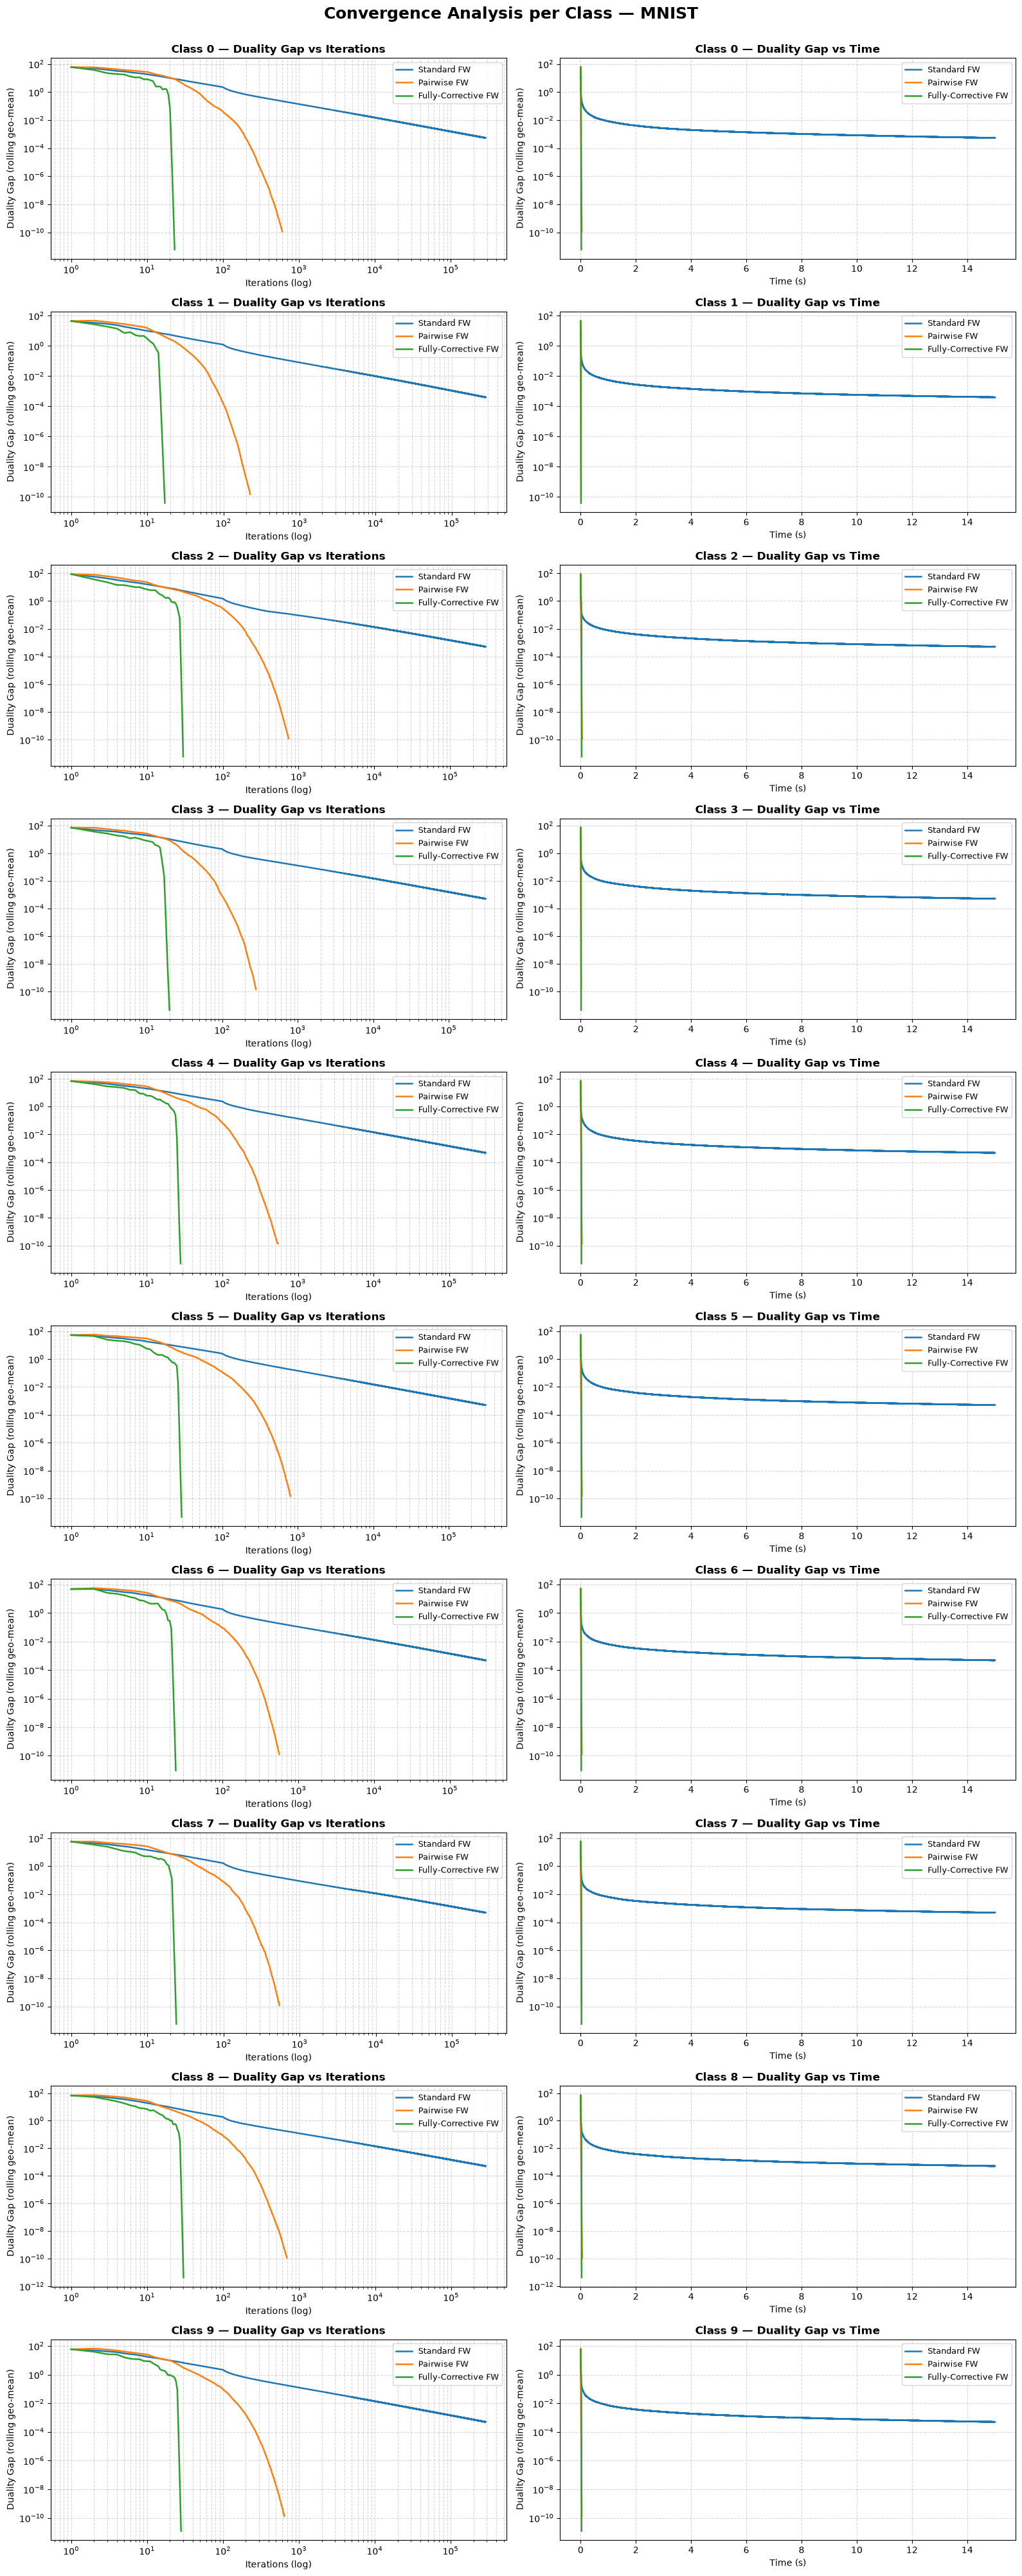

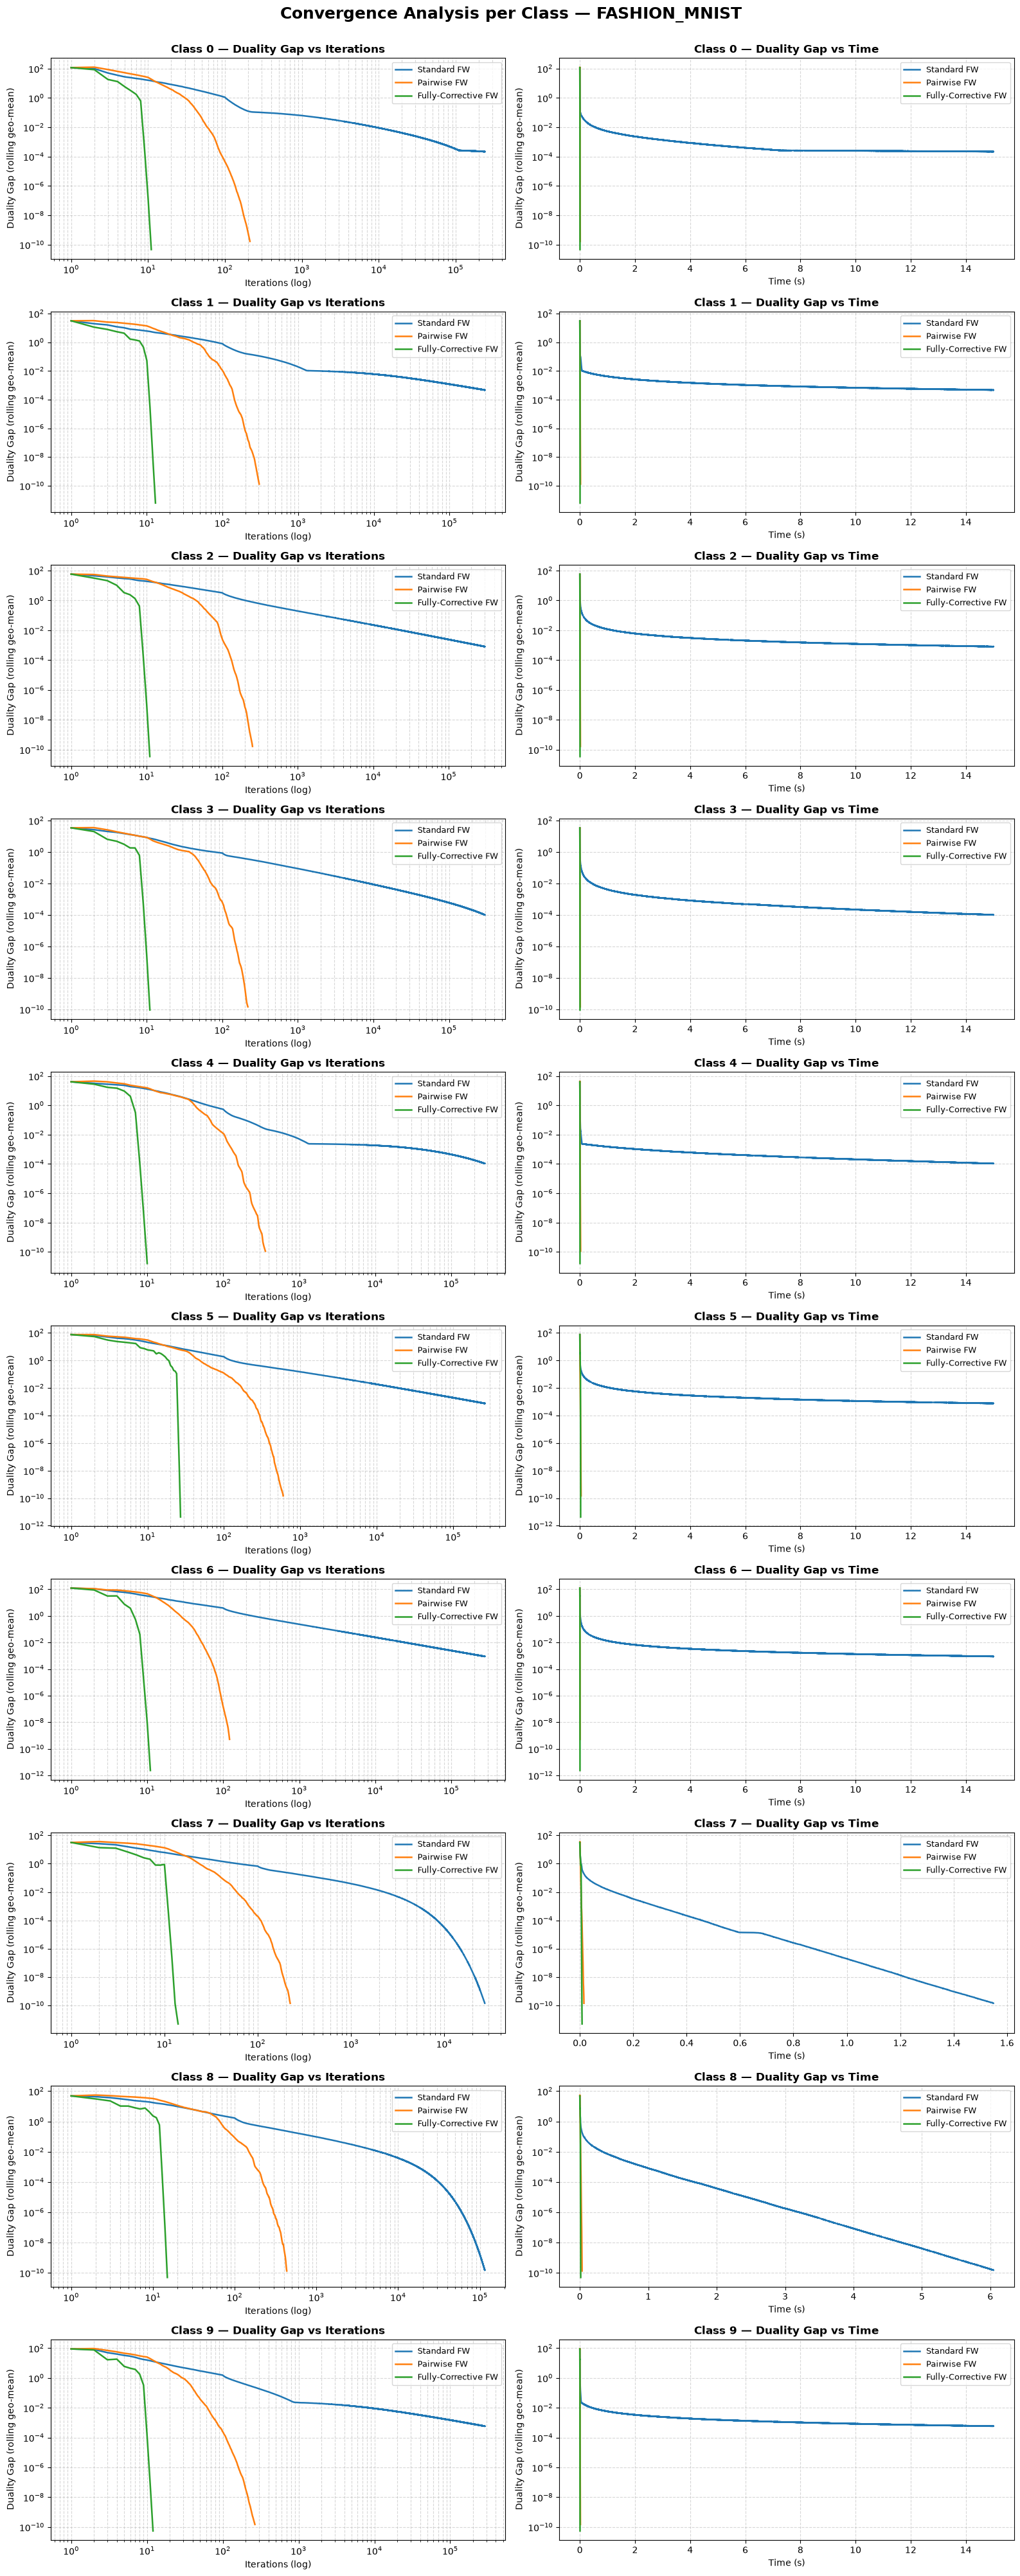

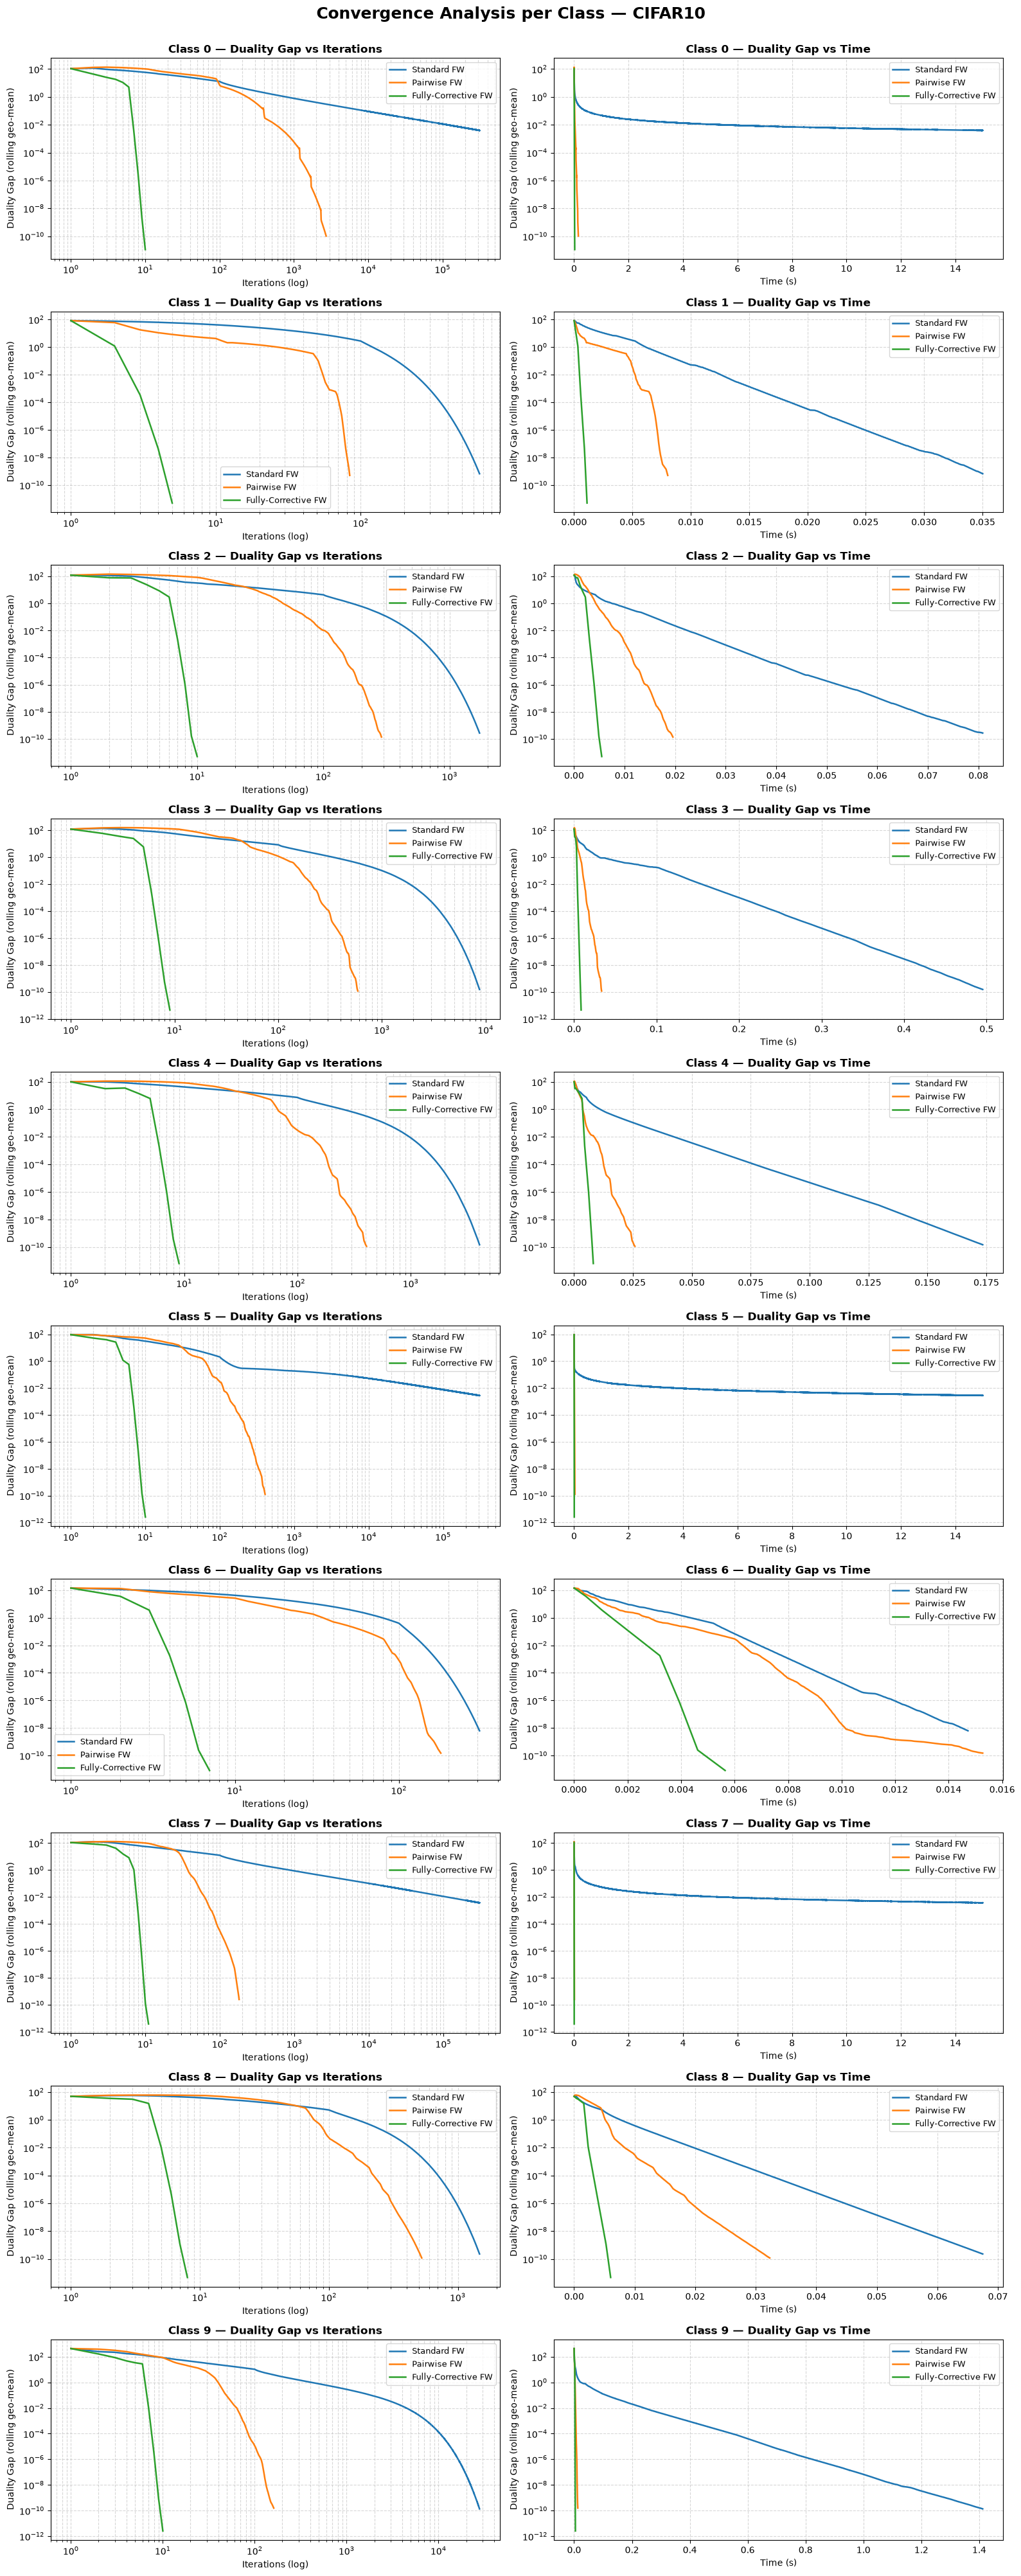

In [3]:
for ds_name in DATASETS:
    plot_convergence_comparison(all_results[ds_name]["models"], dataset_name=ds_name.upper())


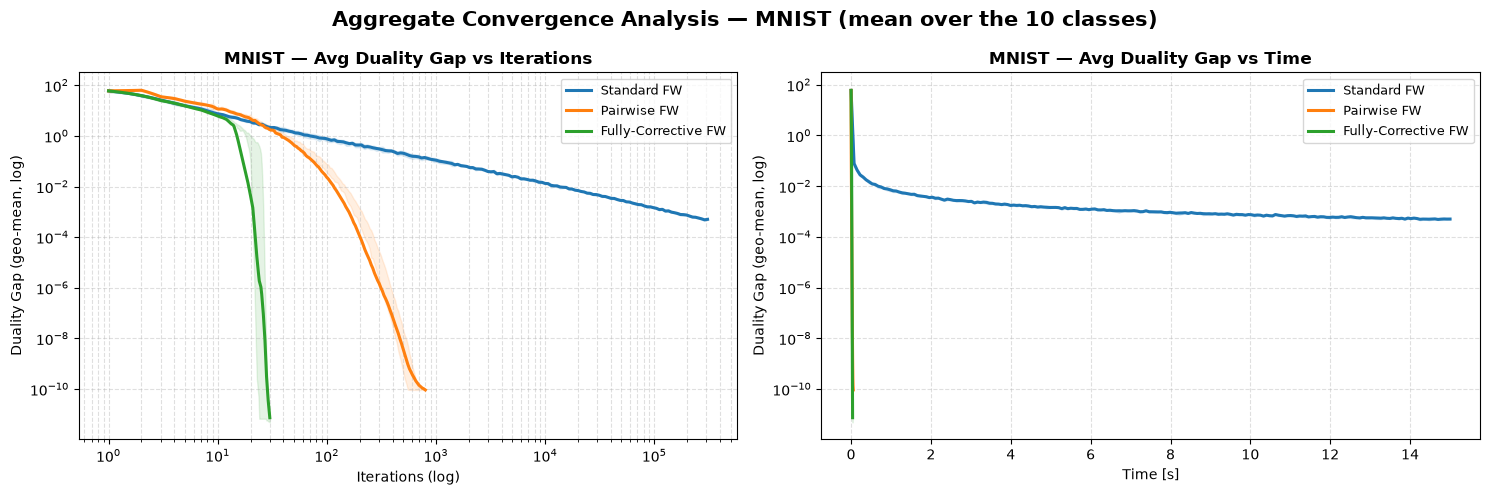

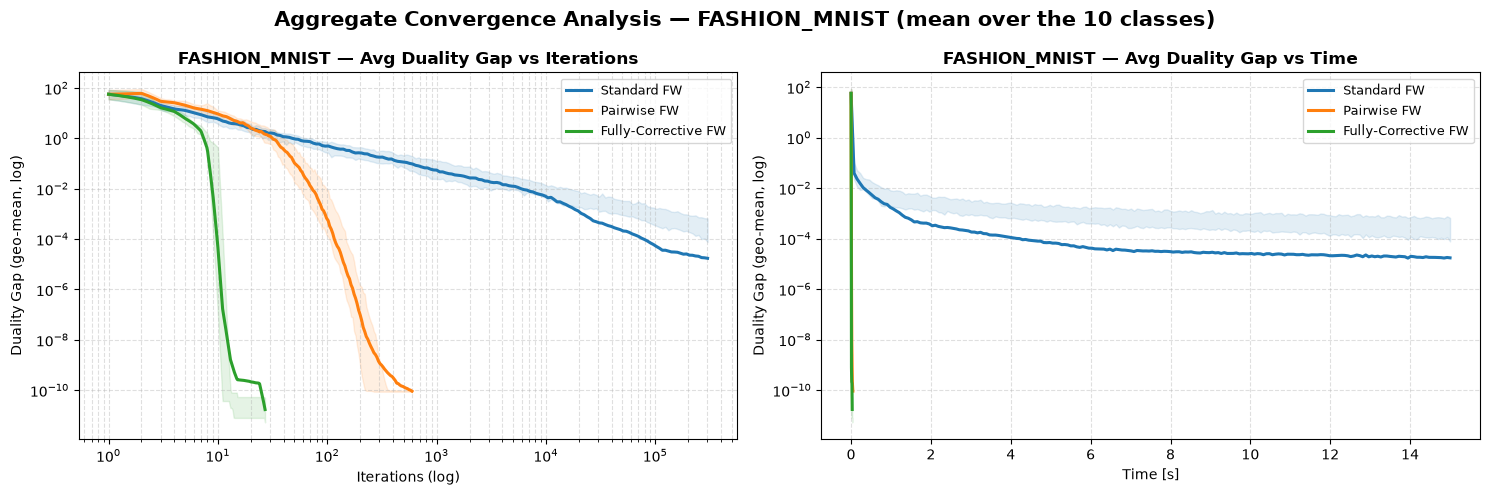

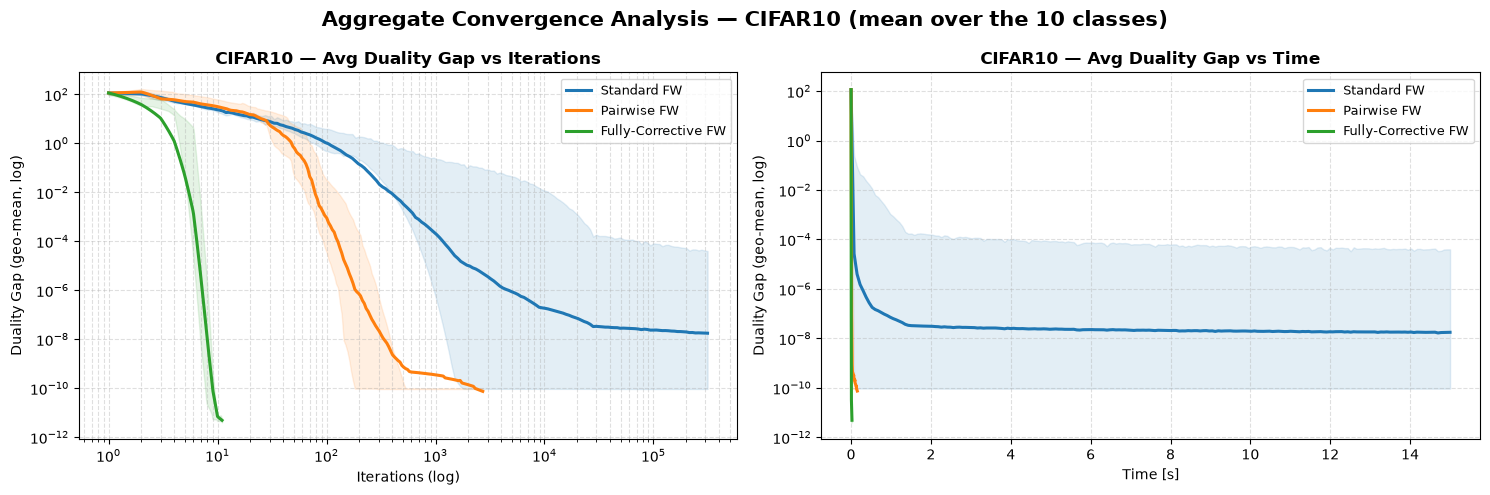

In [4]:
for ds_name in DATASETS:
    plot_dataset_convergence(all_results, ds_name)


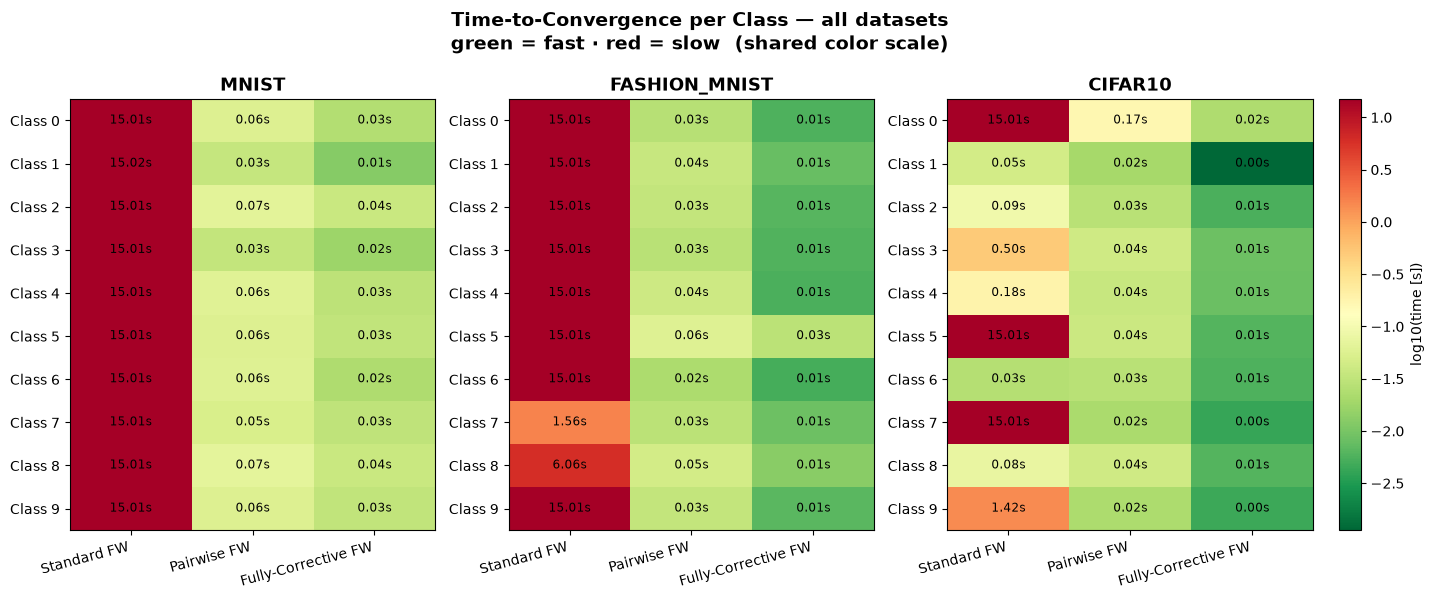

{'mnist':          Standard FW  Pairwise FW  Fully-Corrective FW
 MNIST                                                 
 Class 0    15.012538     0.056272             0.025363
 Class 1    15.017667     0.034409             0.012507
 Class 2    15.012737     0.065675             0.038184
 Class 3    15.013049     0.033307             0.017244
 Class 4    15.013521     0.060888             0.029591
 Class 5    15.009656     0.057218             0.032401
 Class 6    15.012352     0.058064             0.022929
 Class 7    15.013690     0.051026             0.031031
 Class 8    15.011714     0.068498             0.036973
 Class 9    15.012339     0.055736             0.031997,
 'fashion_mnist':                Standard FW  Pairwise FW  Fully-Corrective FW
 FASHION_MNIST                                               
 Class 0          15.012696     0.027147             0.005737
 Class 1          15.012139     0.036249             0.007778
 Class 2          15.013625     0.033530             

In [5]:
combined_time_heatmap(all_results)


## 3. Summary table

Average time, iterations and final duality gap, computed only over the classes where each solver actually converged within the time budget.

In [6]:
summary_df = build_summary_table(all_results)
summary_df


,Dataset,Solver,Converged,Avg Time (s),Avg Iterations,Avg Final Gap
0,MNIST,Standard FW,0/10,NaN,NaN,N/A
1,MNIST,Pairwise FW,10/10,0.05,561.0,9.2335e-11
2,MNIST,Fully-Corrective FW,10/10,0.03,25.0,9.8181e-12
3,FASHION_MNIST,Standard FW,2/10,3.81,70947.0,9.5788e-11
4,FASHION_MNIST,Pairwise FW,10/10,0.04,298.0,9.1009e-11
5,FASHION_MNIST,Fully-Corrective FW,10/10,0.01,14.0,3.0918e-11
6,CIFAR10,Standard FW,7/10,0.34,6410.0,9.3576e-11
7,CIFAR10,Pairwise FW,10/10,0.04,552.0,8.4864e-11
8,CIFAR10,Fully-Corrective FW,10/10,0.01,9.0,5.3831e-12


## 4. Anomaly detection

Each trained MEB acts as a compact model of \"what a normal member of that class looks like\". A test point's anomaly score is its distance from the ball's center, normalized by the ball's radius.


  ANOMALY DETECTION -- MNIST | Standard FW
Samples outside the MEB (ratio > 1): 67 / 14000

[MNIST | Standard FW] Top-3 most / least anomalous samples per class (ratio = dist / R):
  Class 0 | MOST:  #7388 (r=1.05), #2023 (r=1.02), #8085 (r=1.01)
          | LEAST: #5683 (r=0.81), #8191 (r=0.82), #9484 (r=0.82)
  Class 1 | MOST:  #1882 (r=1.09), #8542 (r=1.03), #5112 (r=1.03)
          | LEAST: #5777 (r=0.84), #11651 (r=0.84), #12539 (r=0.85)
  Class 2 | MOST:  #12927 (r=1.08), #9603 (r=1.03), #4487 (r=1.02)
          | LEAST: #2567 (r=0.81), #871 (r=0.82), #7174 (r=0.82)


  Class 3 | MOST:  #5438 (r=1.03), #2751 (r=1.02), #4566 (r=1.02)
          | LEAST: #4796 (r=0.84), #11831 (r=0.84), #1603 (r=0.85)
  Class 4 | MOST:  #11853 (r=1.03), #4574 (r=1.02), #13908 (r=1.01)
          | LEAST: #10787 (r=0.82), #12926 (r=0.83), #11478 (r=0.83)
  Class 5 | MOST:  #10626 (r=1.02), #7913 (r=1.01), #4106 (r=1.00)
          | LEAST: #223 (r=0.82), #7966 (r=0.82), #12860 (r=0.82)
  Class 6 | MOST:  #2551 (r=1.05), #6519 (r=1.05), #1364 (r=1.02)
          | LEAST: #8922 (r=0.85), #3216 (r=0.85), #13577 (r=0.85)
  Class 7 | MOST:  #11202 (r=1.15), #2234 (r=1.03), #2204 (r=1.01)
          | LEAST: #11071 (r=0.83), #10439 (r=0.83), #3740 (r=0.83)
  Class 8 | MOST:  #9671 (r=1.05), #773 (r=1.04), #566 (r=1.04)
          | LEAST: #8095 (r=0.84), #13275 (r=0.86), #9637 (r=0.86)
  Class 9 | MOST:  #13370 (r=1.09), #993 (r=1.04), #6947 (r=1.03)
          | LEAST: #10980 (r=0.83), #9511 (r=0.84), #8146 (r=0.84)


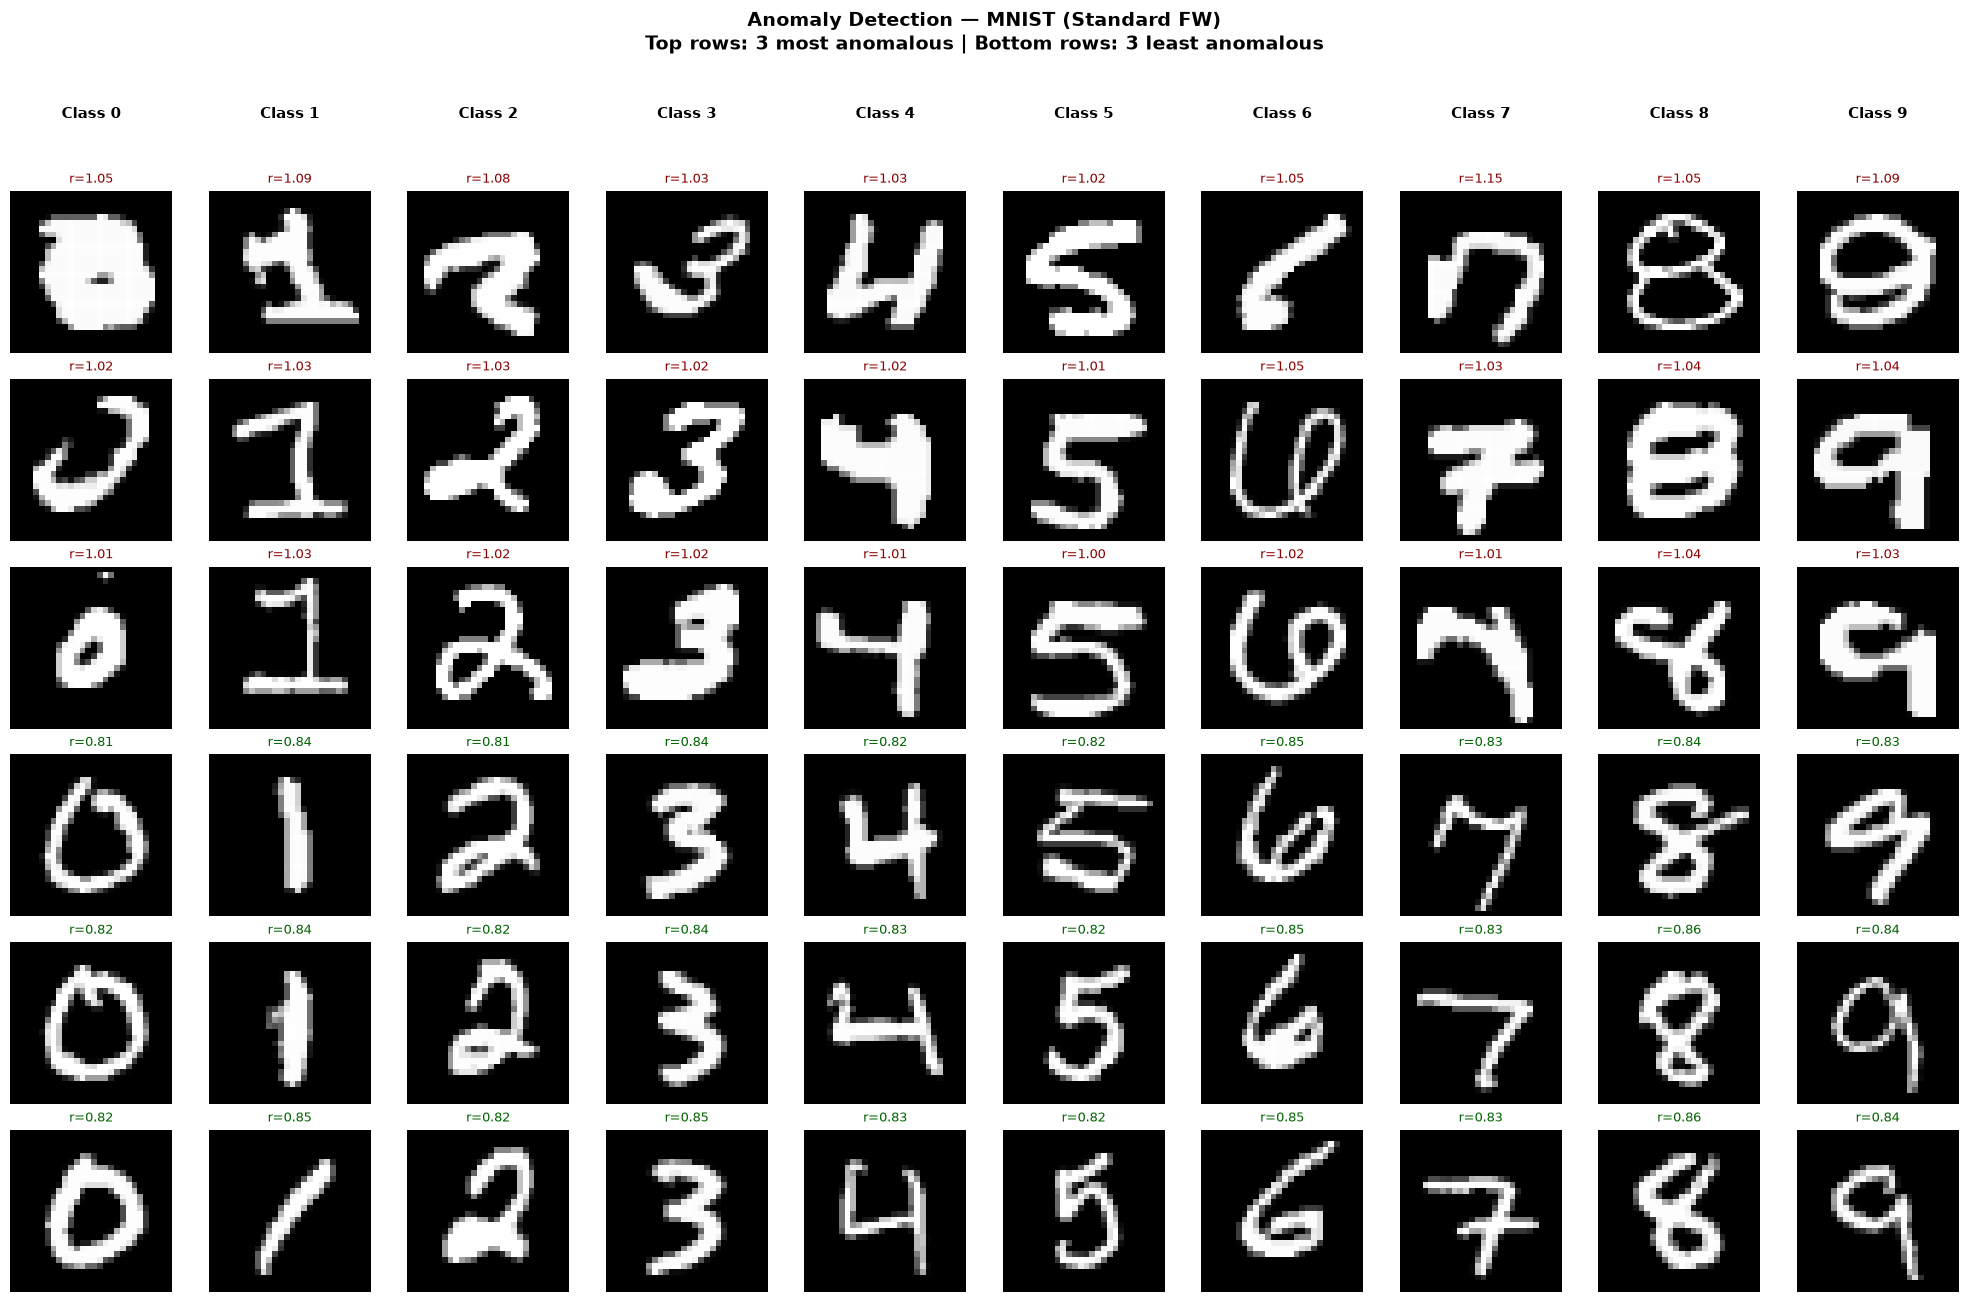


  ANOMALY DETECTION -- MNIST | Pairwise FW
Samples outside the MEB (ratio > 1): 67 / 14000



[MNIST | Pairwise FW] Top-3 most / least anomalous samples per class (ratio = dist / R):
  Class 0 | MOST:  #7388 (r=1.05), #2023 (r=1.02), #8085 (r=1.01)
          | LEAST: #5683 (r=0.81), #8191 (r=0.82), #9484 (r=0.82)
  Class 1 | MOST:  #1882 (r=1.09), #8542 (r=1.03), #5112 (r=1.03)
          | LEAST: #5777 (r=0.84), #11651 (r=0.84), #12539 (r=0.85)
  Class 2 | MOST:  #12927 (r=1.08), #9603 (r=1.03), #4487 (r=1.02)
          | LEAST: #2567 (r=0.81), #871 (r=0.82), #7174 (r=0.82)
  Class 3 | MOST:  #5438 (r=1.03), #2751 (r=1.02), #4566 (r=1.02)
          | LEAST: #4796 (r=0.84), #11831 (r=0.84), #1603 (r=0.85)
  Class 4 | MOST:  #11853 (r=1.03), #4574 (r=1.02), #13908 (r=1.01)
          | LEAST: #10787 (r=0.82), #12926 (r=0.83), #11478 (r=0.83)
  Class 5 | MOST:  #10626 (r=1.02), #7913 (r=1.01), #4106 (r=1.00)
          | LEAST: #223 (r=0.82), #7966 (r=0.82), #12860 (r=0.82)
  Class 6 | MOST:  #2551 (r=1.05), #6519 (r=1.05), #1364 (r=1.02)
          | LEAST: #8922 (r=0.85), #3216 (r

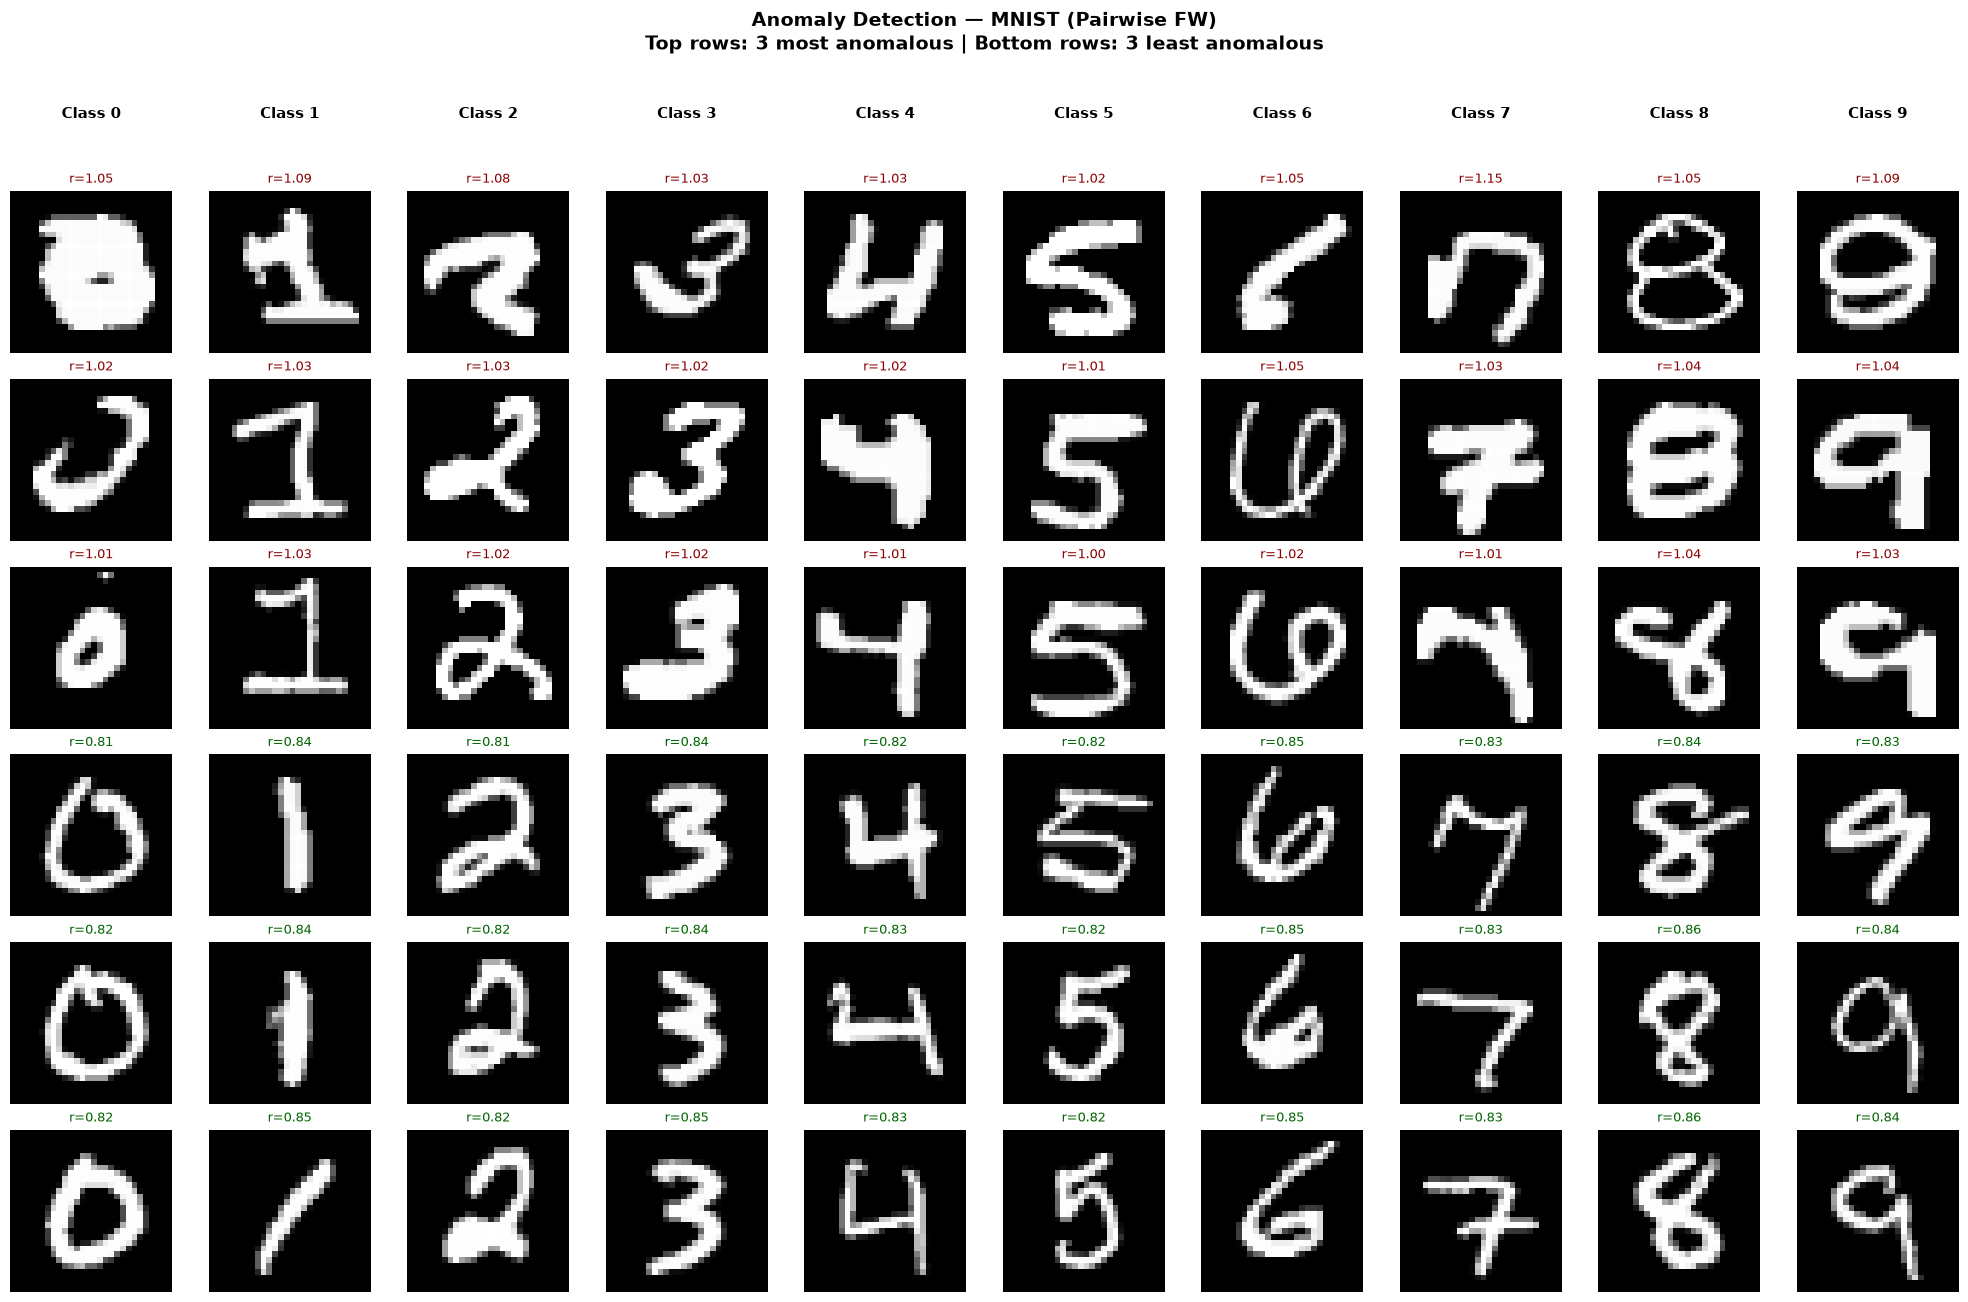


  ANOMALY DETECTION -- MNIST | Fully-Corrective FW
Samples outside the MEB (ratio > 1): 67 / 14000

[MNIST | Fully-Corrective FW] Top-3 most / least anomalous samples per class (ratio = dist / R):
  Class 0 | MOST:  #7388 (r=1.05), #2023 (r=1.02), #8085 (r=1.01)
          | LEAST: #5683 (r=0.81), #8191 (r=0.82), #9484 (r=0.82)
  Class 1 | MOST:  #1882 (r=1.09), #8542 (r=1.03), #5112 (r=1.03)
          | LEAST: #5777 (r=0.84), #11651 (r=0.84), #12539 (r=0.85)
  Class 2 | MOST:  #12927 (r=1.08), #9603 (r=1.03), #4487 (r=1.02)
          | LEAST: #2567 (r=0.81), #871 (r=0.82), #7174 (r=0.82)
  Class 3 | MOST:  #5438 (r=1.03), #2751 (r=1.02), #4566 (r=1.02)
          | LEAST: #4796 (r=0.84), #11831 (r=0.84), #1603 (r=0.85)
  Class 4 | MOST:  #11853 (r=1.03), #4574 (r=1.02), #13908 (r=1.01)
          | LEAST: #10787 (r=0.82), #12926 (r=0.83), #11478 (r=0.83)
  Class 5 | MOST:  #10626 (r=1.02), #7913 (r=1.01), #4106 (r=1.00)
          | LEAST: #223 (r=0.82), #7966 (r=0.82), #12860 (r=0.82)
 

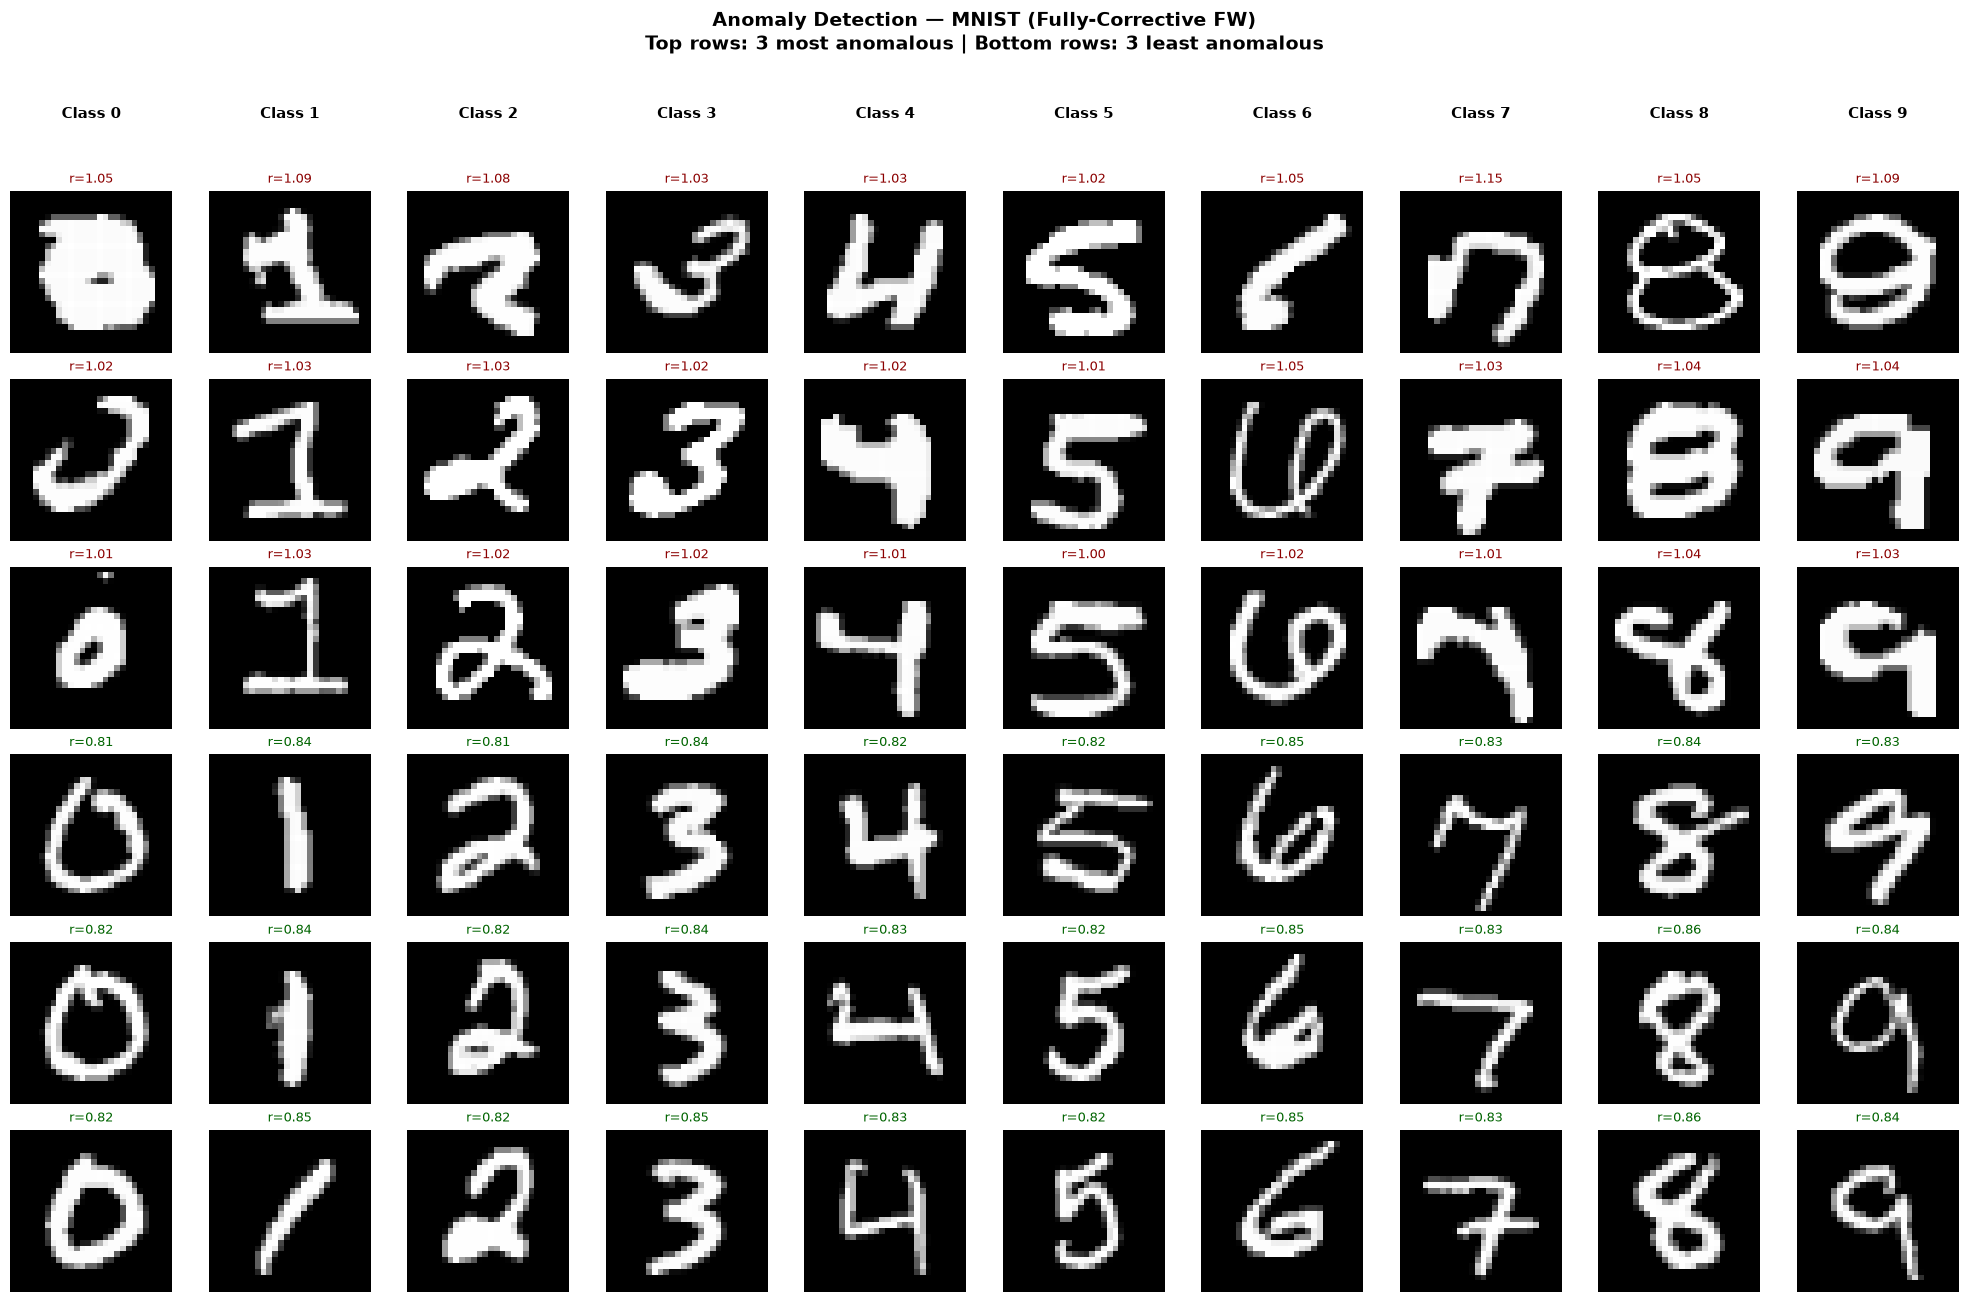


  ANOMALY DETECTION -- FASHION_MNIST | Standard FW
Samples outside the MEB (ratio > 1): 31 / 14000



[FASHION_MNIST | Standard FW] Top-3 most / least anomalous samples per class (ratio = dist / R):
  Class 0 | MOST:  #8692 (r=1.07), #5608 (r=1.03), #10034 (r=1.02)
          | LEAST: #8439 (r=0.45), #10530 (r=0.47), #1049 (r=0.48)
  Class 1 | MOST:  #9023 (r=1.06), #8085 (r=1.04), #1652 (r=1.01)
          | LEAST: #2648 (r=0.56), #698 (r=0.59), #13079 (r=0.63)
  Class 2 | MOST:  #1480 (r=1.02), #10271 (r=1.01), #10754 (r=0.99)
          | LEAST: #8226 (r=0.42), #8497 (r=0.44), #12390 (r=0.45)
  Class 3 | MOST:  #12532 (r=1.01), #9723 (r=1.00), #427 (r=1.00)
          | LEAST: #9434 (r=0.43), #7318 (r=0.46), #4644 (r=0.49)
  Class 4 | MOST:  #11401 (r=1.03), #7501 (r=1.03), #3074 (r=1.01)
          | LEAST: #11592 (r=0.44), #471 (r=0.45), #3688 (r=0.46)
  Class 5 | MOST:  #11033 (r=1.07), #157 (r=1.04), #11625 (r=1.02)
          | LEAST: #4786 (r=0.54), #11147 (r=0.60), #1685 (r=0.62)
  Class 6 | MOST:  #4406 (r=1.00), #13855 (r=0.99), #3834 (r=0.99)
          | LEAST: #2577 (r=0.43), 

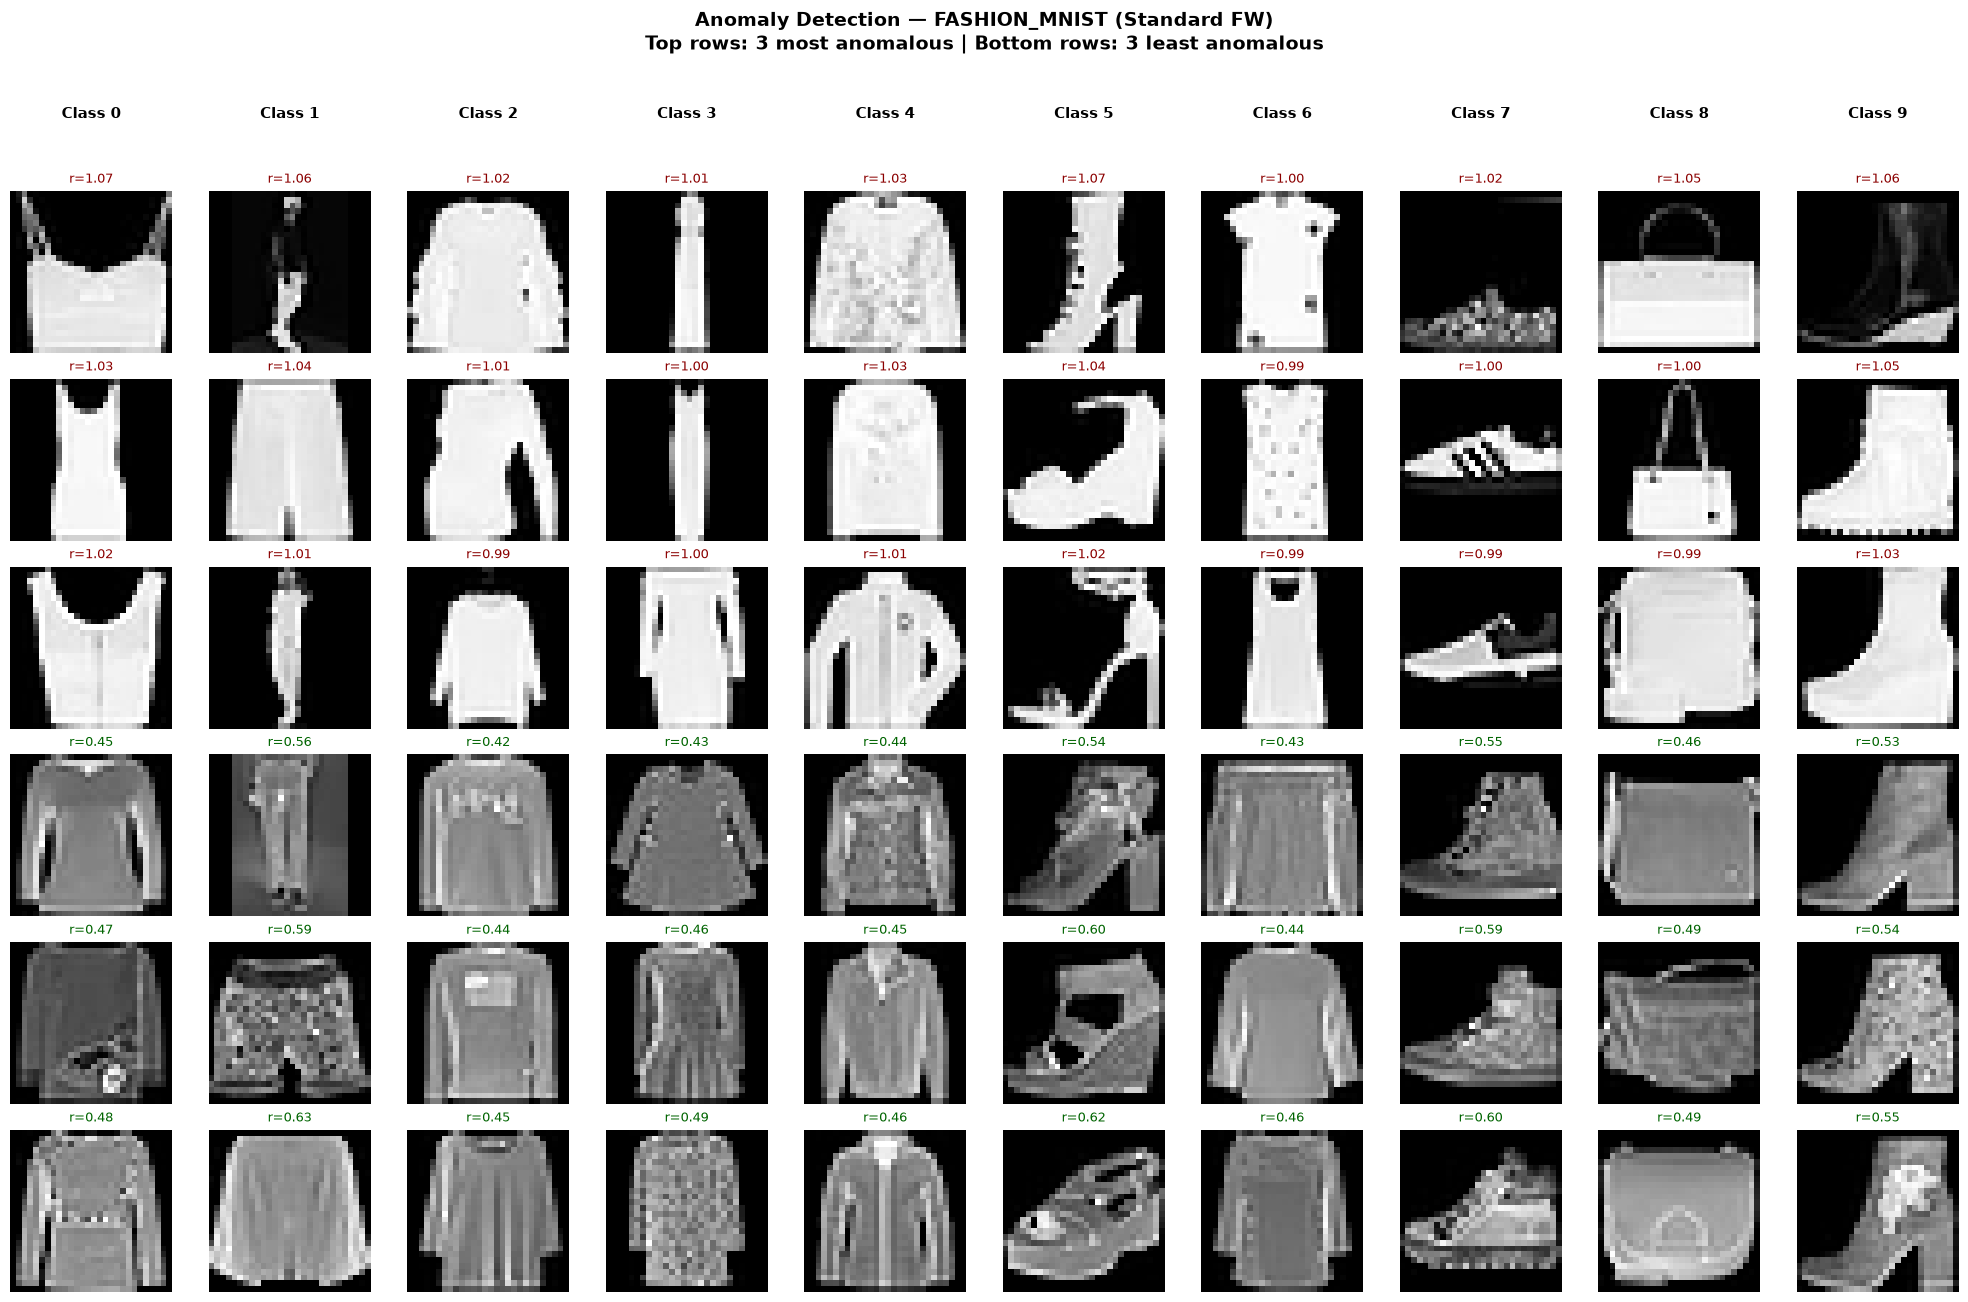


  ANOMALY DETECTION -- FASHION_MNIST | Pairwise FW
Samples outside the MEB (ratio > 1): 31 / 14000

[FASHION_MNIST | Pairwise FW] Top-3 most / least anomalous samples per class (ratio = dist / R):
  Class 0 | MOST:  #8692 (r=1.07), #5608 (r=1.03), #10034 (r=1.02)
          | LEAST: #8439 (r=0.45), #10530 (r=0.47), #1049 (r=0.48)
  Class 1 | MOST:  #9023 (r=1.06), #8085 (r=1.04), #1652 (r=1.01)
          | LEAST: #2648 (r=0.56), #698 (r=0.59), #13079 (r=0.63)
  Class 2 | MOST:  #1480 (r=1.02), #10271 (r=1.01), #10754 (r=0.99)
          | LEAST: #8226 (r=0.42), #8497 (r=0.44), #12390 (r=0.45)
  Class 3 | MOST:  #12532 (r=1.01), #9723 (r=1.00), #427 (r=1.00)
          | LEAST: #9434 (r=0.43), #7318 (r=0.46), #4644 (r=0.49)
  Class 4 | MOST:  #11401 (r=1.03), #7501 (r=1.03), #3074 (r=1.01)
          | LEAST: #11592 (r=0.44), #471 (r=0.45), #3688 (r=0.46)
  Class 5 | MOST:  #11033 (r=1.07), #157 (r=1.04), #11625 (r=1.02)
          | LEAST: #4786 (r=0.54), #11147 (r=0.60), #1685 (r=0.62)
  

  Class 9 | MOST:  #9361 (r=1.06), #12867 (r=1.05), #1465 (r=1.03)
          | LEAST: #5473 (r=0.53), #556 (r=0.54), #30 (r=0.55)


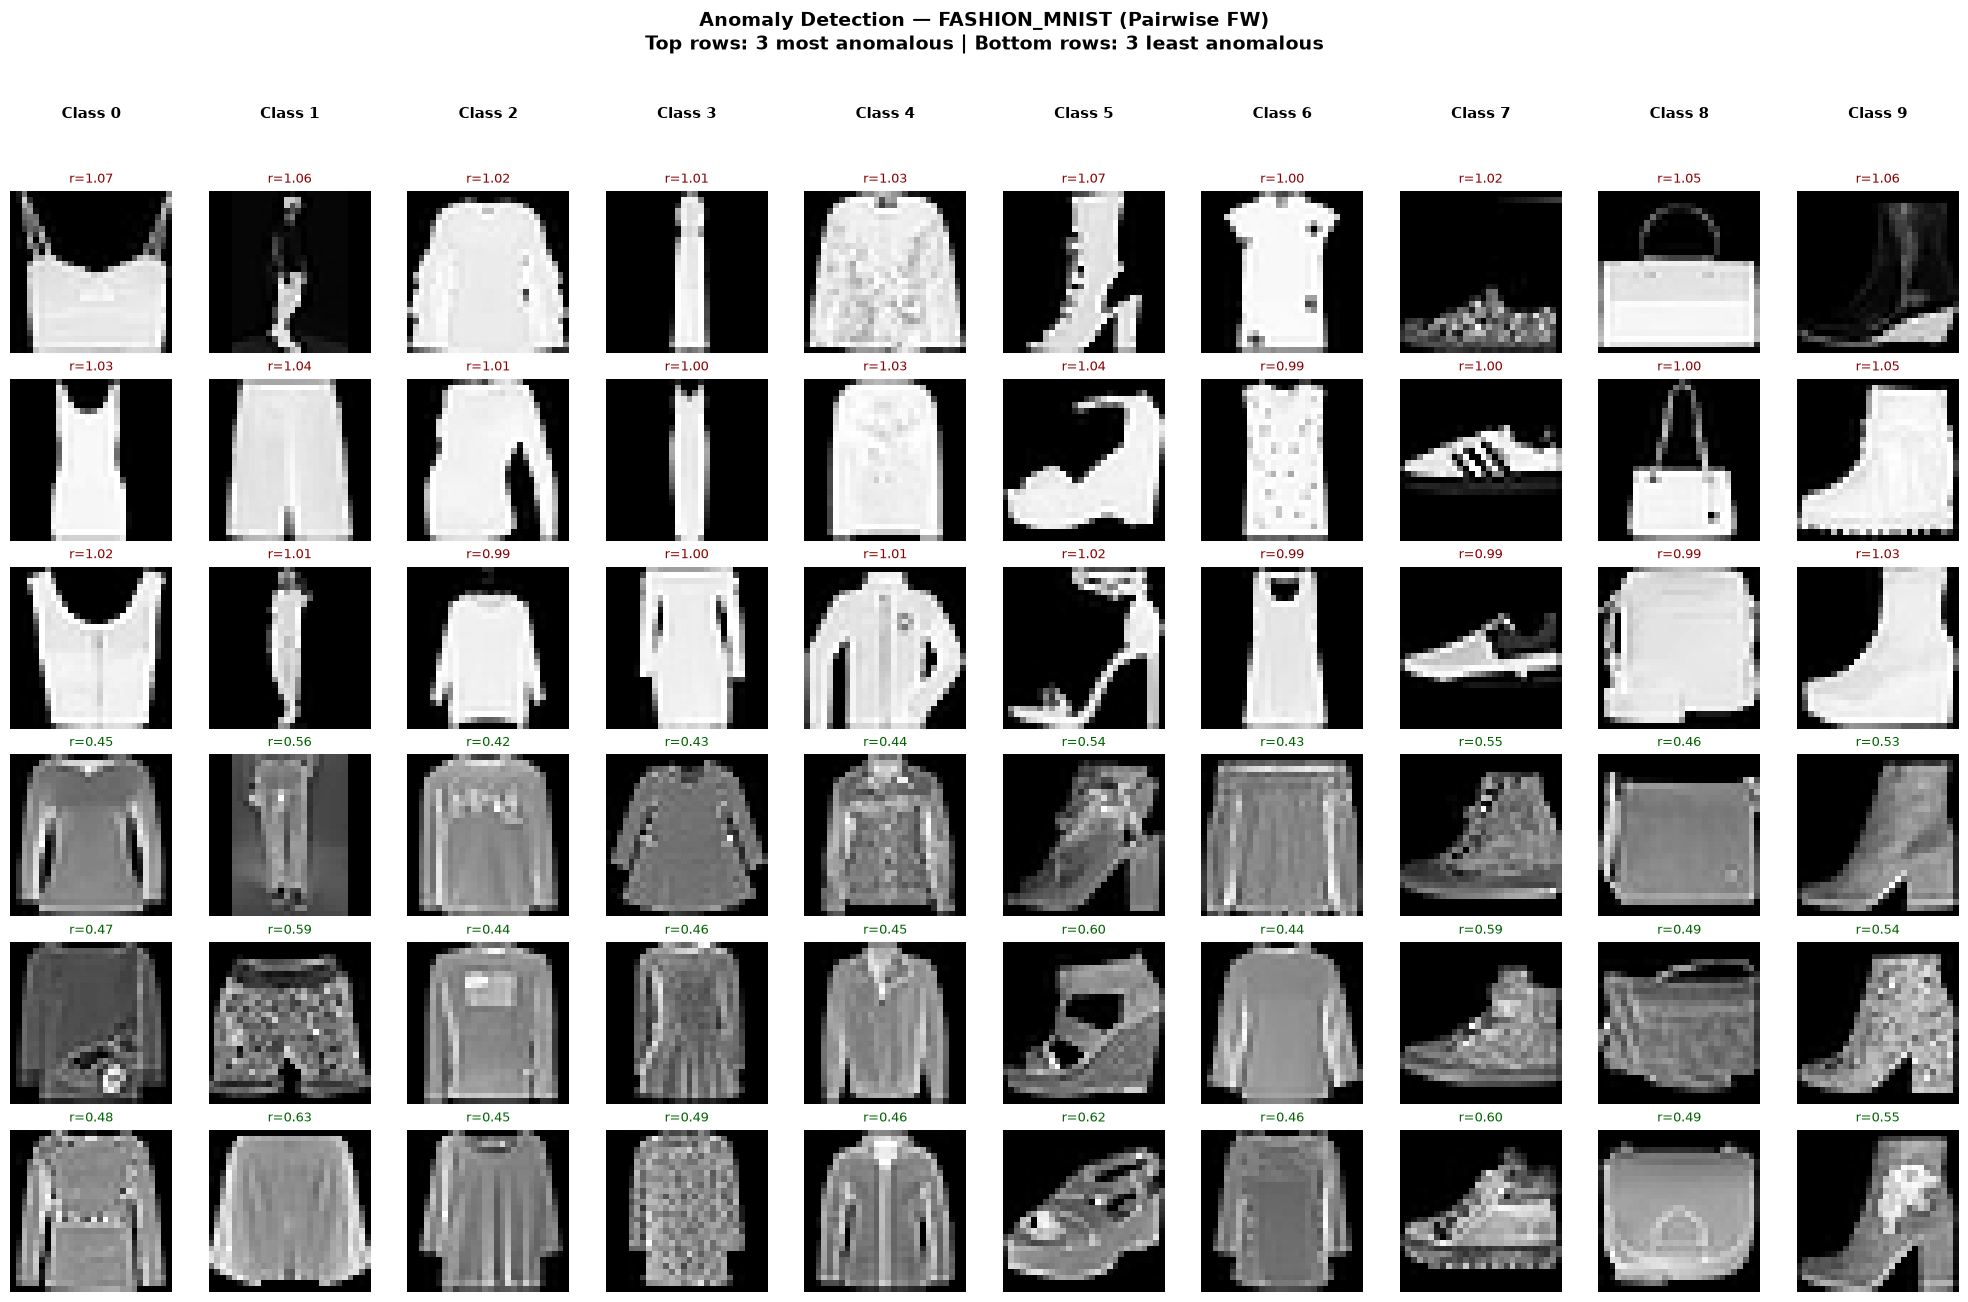


  ANOMALY DETECTION -- FASHION_MNIST | Fully-Corrective FW
Samples outside the MEB (ratio > 1): 31 / 14000

[FASHION_MNIST | Fully-Corrective FW] Top-3 most / least anomalous samples per class (ratio = dist / R):
  Class 0 | MOST:  #8692 (r=1.07), #5608 (r=1.03), #10034 (r=1.02)
          | LEAST: #8439 (r=0.45), #10530 (r=0.47), #1049 (r=0.48)
  Class 1 | MOST:  #9023 (r=1.06), #8085 (r=1.04), #1652 (r=1.01)
          | LEAST: #2648 (r=0.56), #698 (r=0.59), #13079 (r=0.63)
  Class 2 | MOST:  #1480 (r=1.02), #10271 (r=1.01), #10754 (r=0.99)
          | LEAST: #8226 (r=0.42), #8497 (r=0.44), #12390 (r=0.45)
  Class 3 | MOST:  #12532 (r=1.01), #9723 (r=1.00), #427 (r=1.00)
          | LEAST: #9434 (r=0.43), #7318 (r=0.46), #4644 (r=0.49)
  Class 4 | MOST:  #11401 (r=1.03), #7501 (r=1.03), #3074 (r=1.01)
          | LEAST: #11592 (r=0.44), #471 (r=0.45), #3688 (r=0.46)
  Class 5 | MOST:  #11033 (r=1.07), #157 (r=1.04), #11625 (r=1.02)
          | LEAST: #4786 (r=0.54), #11147 (r=0.60), #

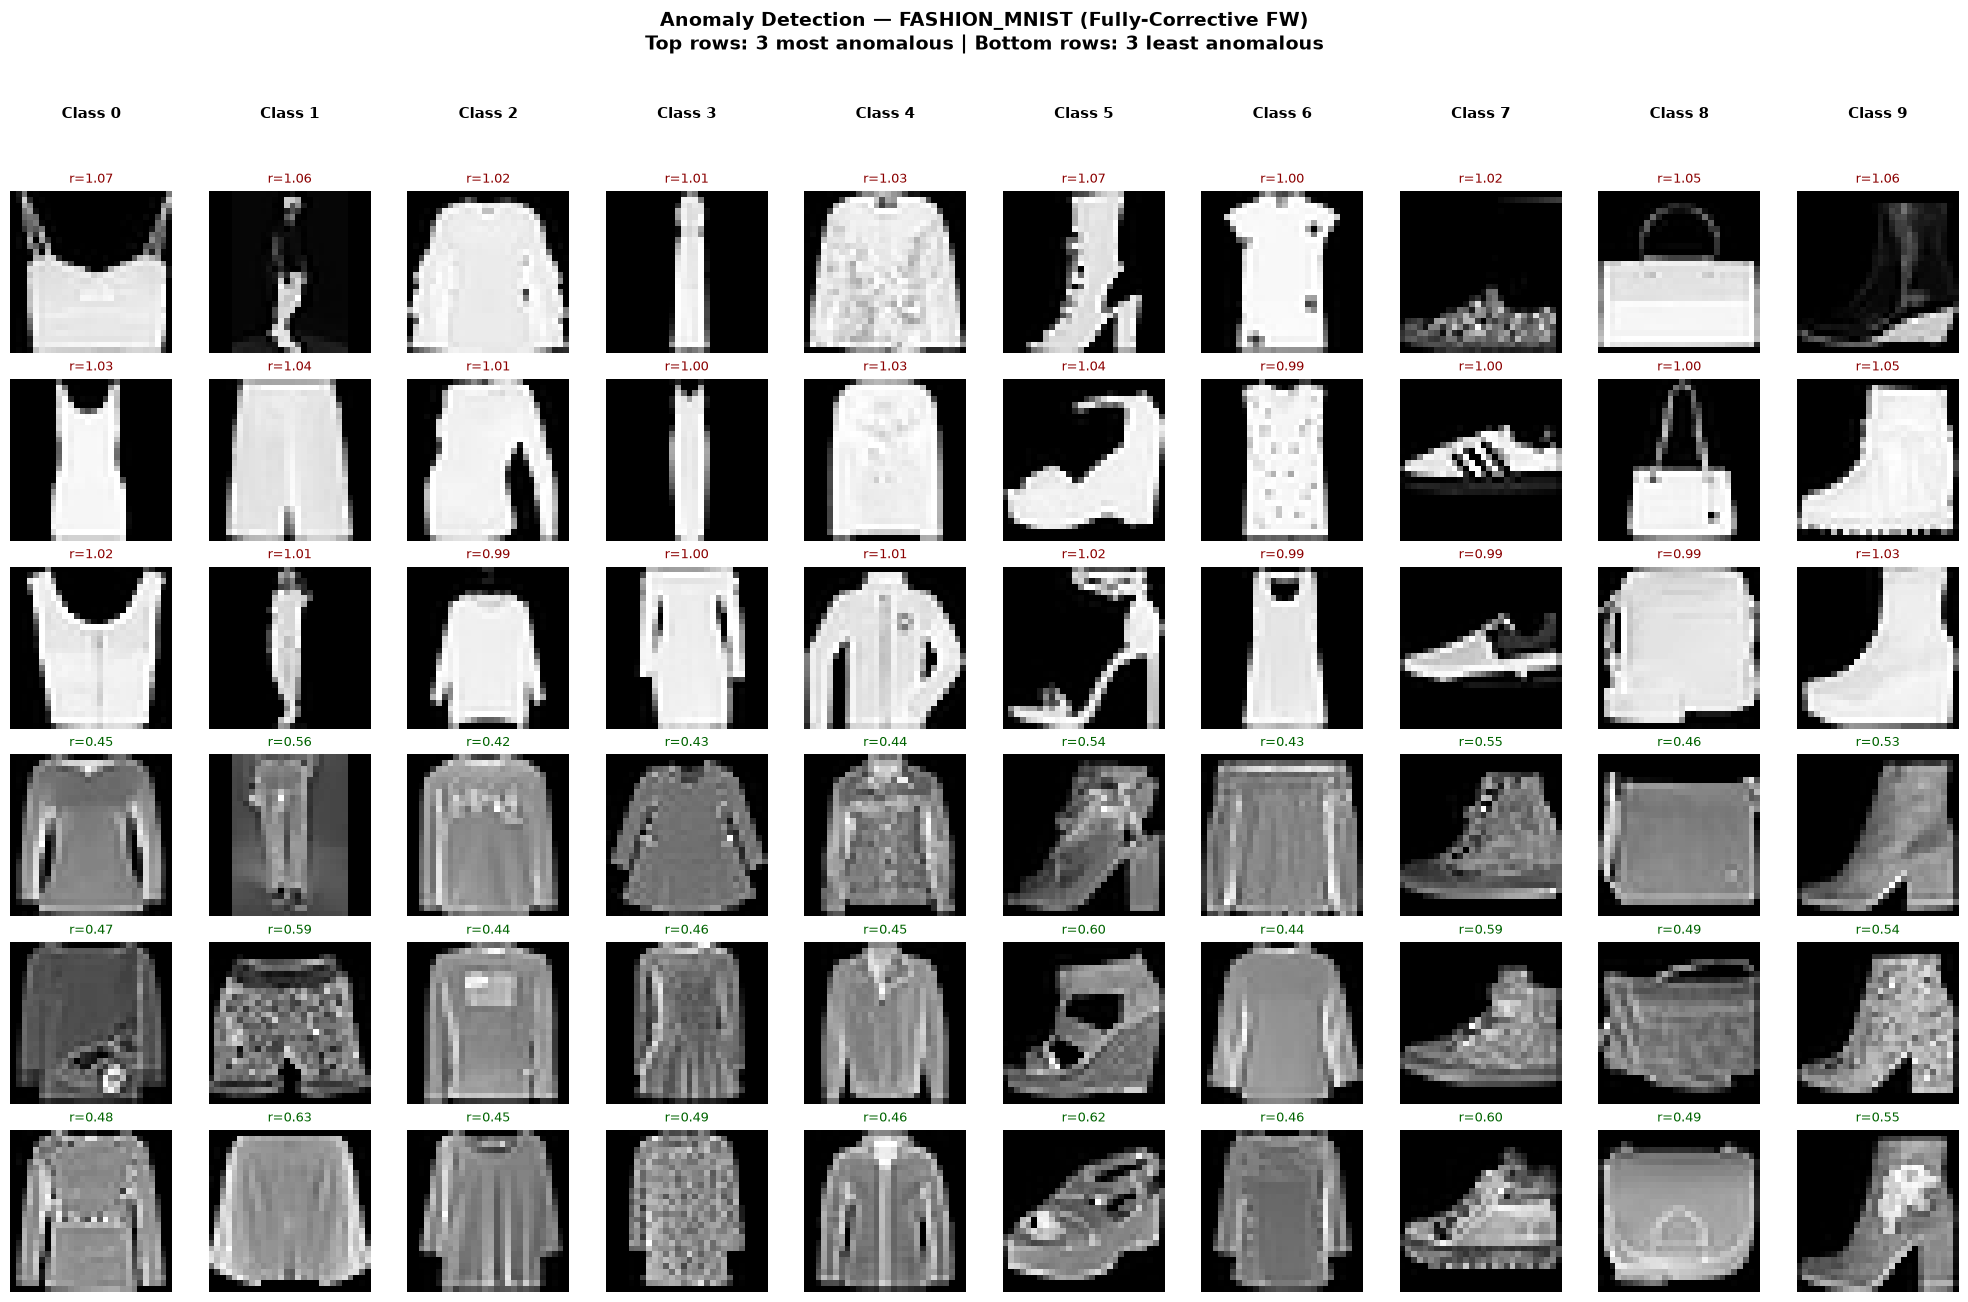


  ANOMALY DETECTION -- CIFAR10 | Standard FW


Samples outside the MEB (ratio > 1): 22 / 12000

[CIFAR10 | Standard FW] Top-3 most / least anomalous samples per class (ratio = dist / R):
  Class 0 | MOST:  #2915 (r=0.96), #211 (r=0.96), #1255 (r=0.95)
          | LEAST: #6515 (r=0.18), #77 (r=0.19), #2503 (r=0.21)
  Class 1 | MOST:  #11243 (r=0.98), #1430 (r=0.96), #6965 (r=0.95)
          | LEAST: #9444 (r=0.29), #6205 (r=0.32), #244 (r=0.32)
  Class 2 | MOST:  #934 (r=1.05), #2686 (r=1.03), #11620 (r=1.01)
          | LEAST: #5042 (r=0.24), #8255 (r=0.25), #2784 (r=0.25)
  Class 3 | MOST:  #1138 (r=1.01), #8306 (r=0.99), #2999 (r=0.99)
          | LEAST: #11395 (r=0.23), #1445 (r=0.24), #8425 (r=0.24)
  Class 4 | MOST:  #4619 (r=1.02), #2240 (r=1.02), #9569 (r=0.98)
          | LEAST: #10937 (r=0.21), #7592 (r=0.22), #659 (r=0.24)
  Class 5 | MOST:  #7361 (r=1.03), #8819 (r=0.97), #6270 (r=0.96)
          | LEAST: #3104 (r=0.24), #11340 (r=0.25), #3326 (r=0.25)
  Class 6 | MOST:  #1441 (r=1.08), #5442 (r=1.07), #4658 (r=0.97)
   

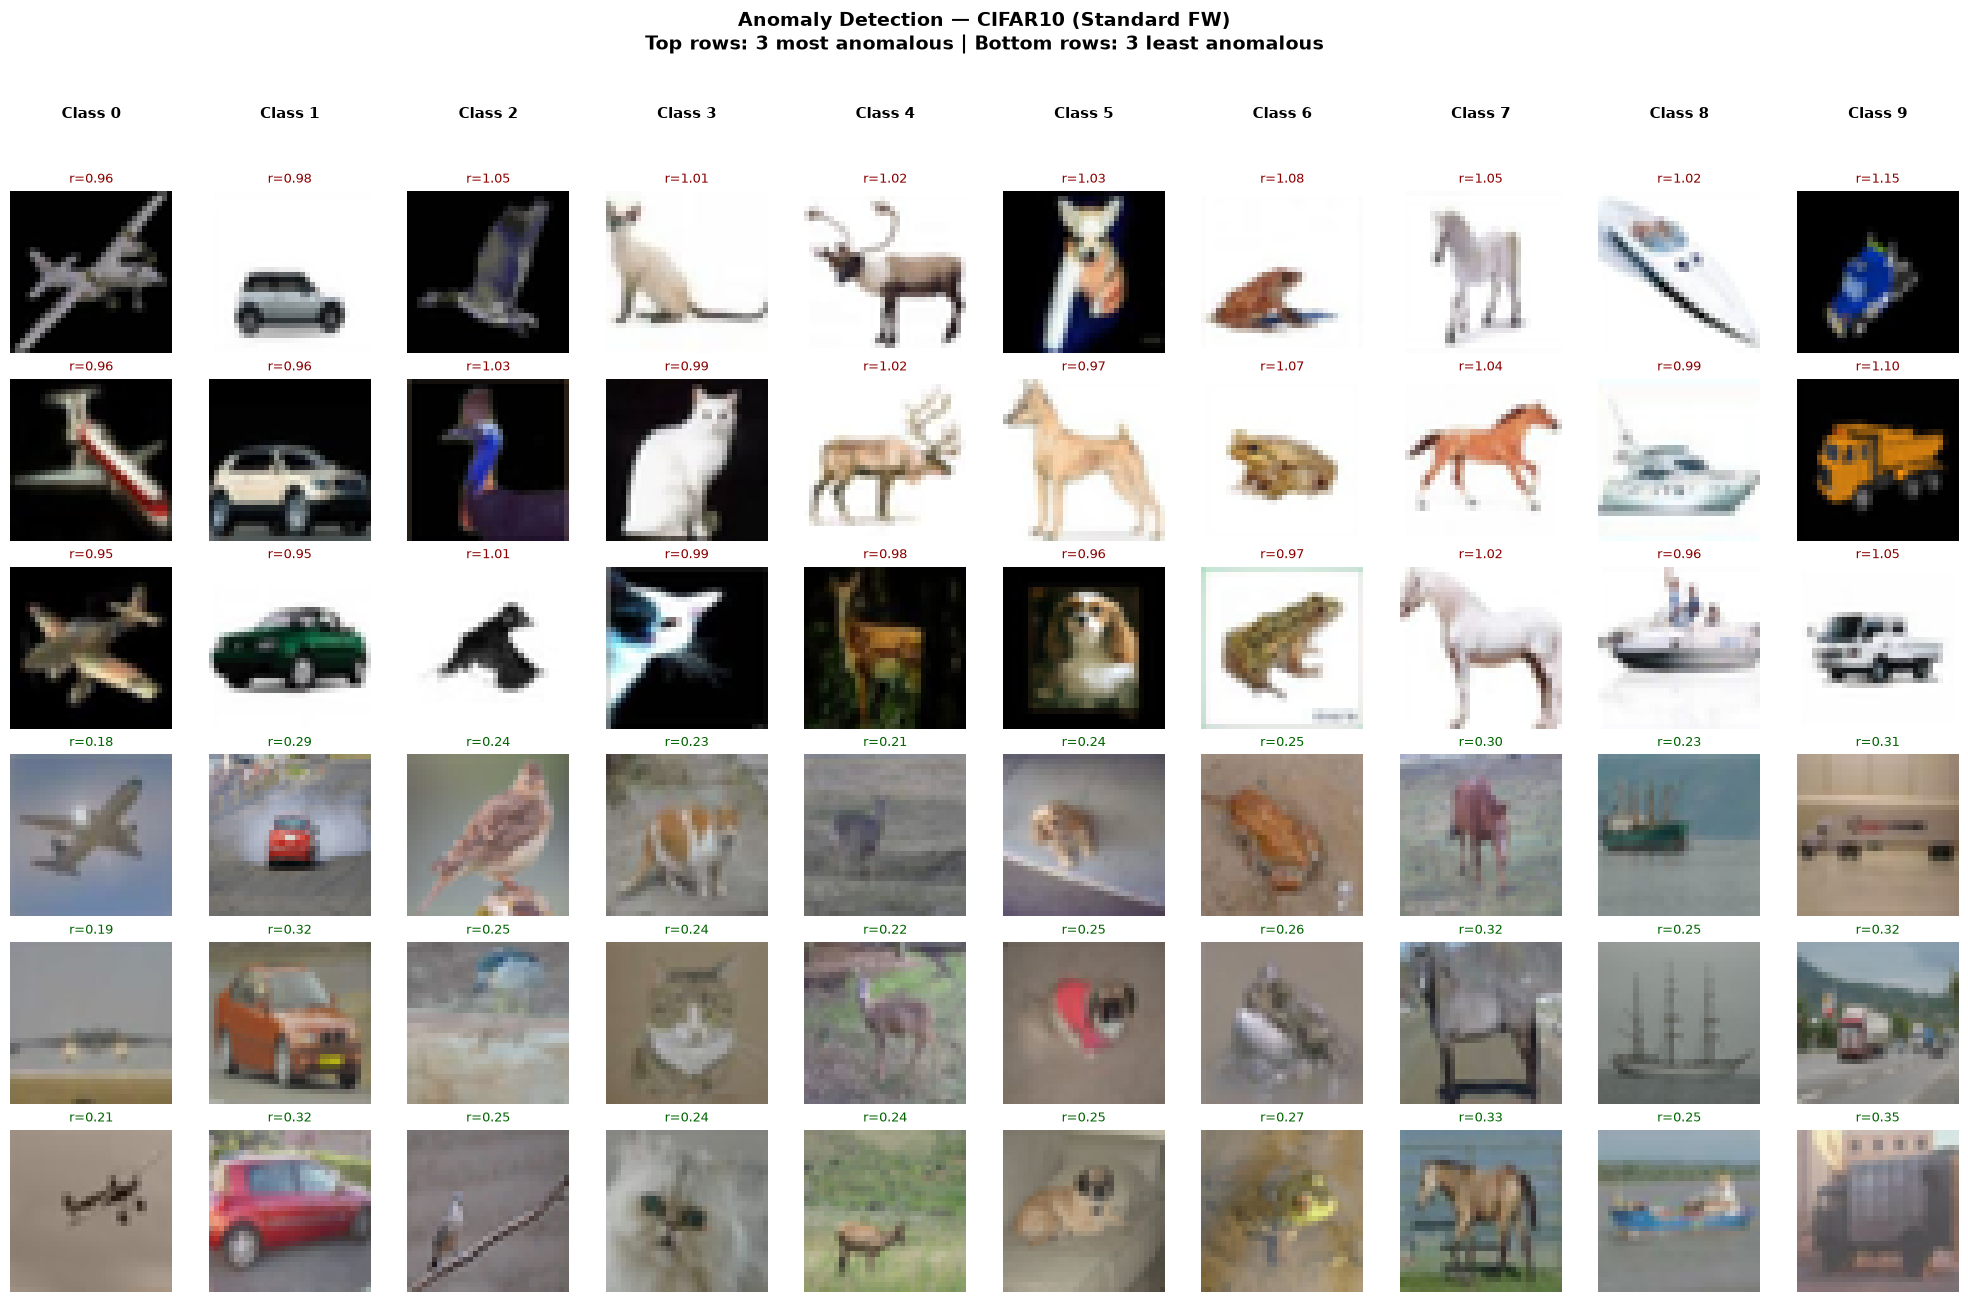


  ANOMALY DETECTION -- CIFAR10 | Pairwise FW
Samples outside the MEB (ratio > 1): 22 / 12000

[CIFAR10 | Pairwise FW] Top-3 most / least anomalous samples per class (ratio = dist / R):


  Class 0 | MOST:  #2915 (r=0.96), #211 (r=0.96), #1255 (r=0.95)
          | LEAST: #6515 (r=0.18), #77 (r=0.19), #2503 (r=0.21)
  Class 1 | MOST:  #11243 (r=0.98), #1430 (r=0.96), #6965 (r=0.95)
          | LEAST: #9444 (r=0.29), #6205 (r=0.32), #244 (r=0.32)
  Class 2 | MOST:  #934 (r=1.05), #2686 (r=1.03), #11620 (r=1.01)
          | LEAST: #5042 (r=0.24), #8255 (r=0.25), #2784 (r=0.25)
  Class 3 | MOST:  #1138 (r=1.01), #8306 (r=0.99), #2999 (r=0.99)
          | LEAST: #11395 (r=0.23), #1445 (r=0.24), #8425 (r=0.24)
  Class 4 | MOST:  #4619 (r=1.02), #2240 (r=1.02), #9569 (r=0.98)
          | LEAST: #10937 (r=0.21), #7592 (r=0.22), #659 (r=0.24)
  Class 5 | MOST:  #7361 (r=1.03), #8819 (r=0.97), #6270 (r=0.96)
          | LEAST: #3104 (r=0.24), #11340 (r=0.25), #3326 (r=0.25)
  Class 6 | MOST:  #1441 (r=1.08), #5442 (r=1.07), #4658 (r=0.97)
          | LEAST: #2355 (r=0.25), #2746 (r=0.26), #11939 (r=0.27)
  Class 7 | MOST:  #2225 (r=1.05), #9411 (r=1.04), #2898 (r=1.02)
          

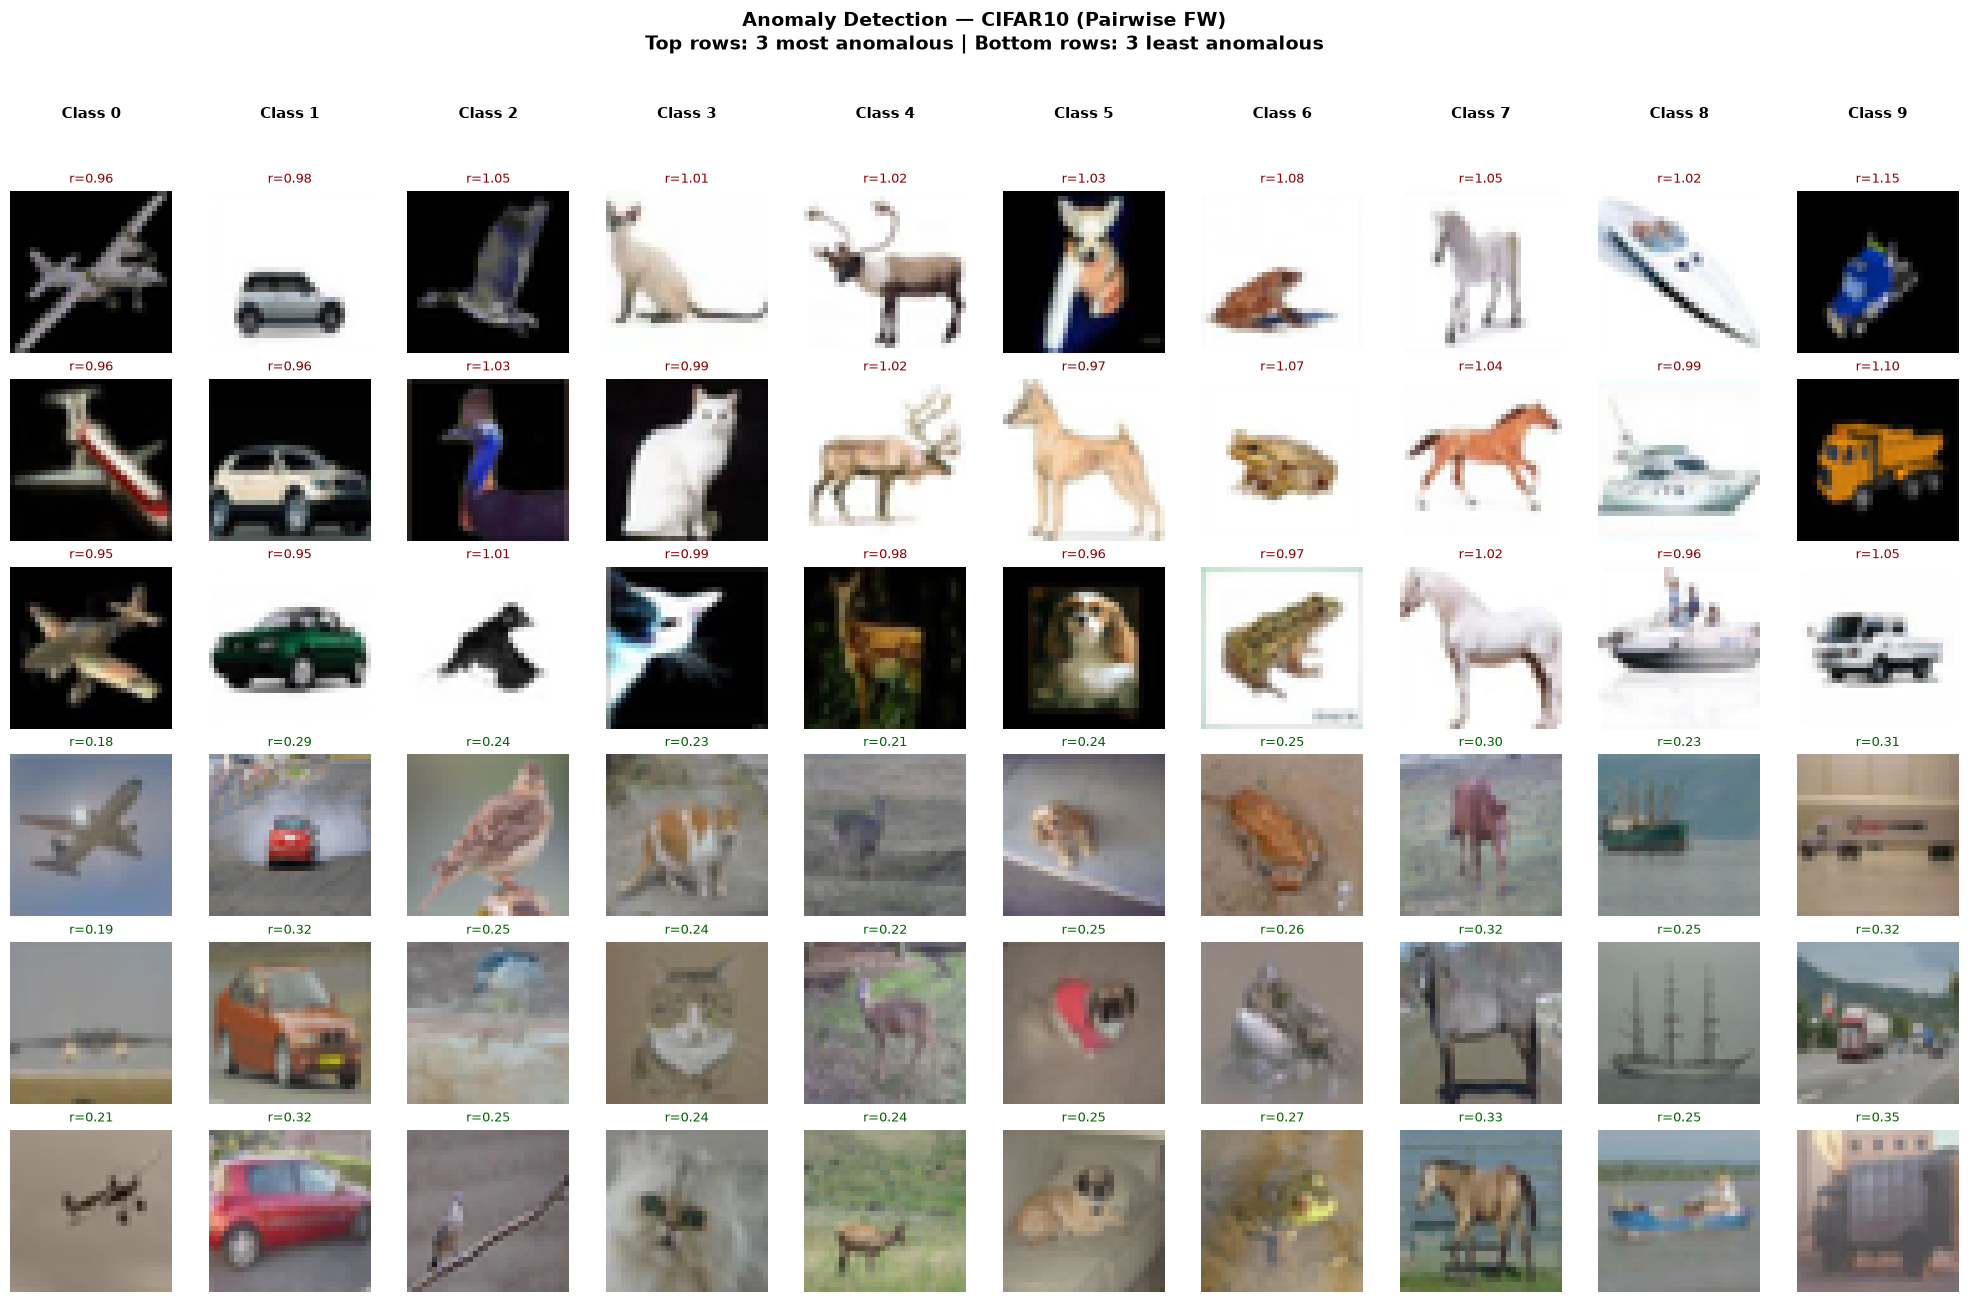


  ANOMALY DETECTION -- CIFAR10 | Fully-Corrective FW
Samples outside the MEB (ratio > 1): 22 / 12000

[CIFAR10 | Fully-Corrective FW] Top-3 most / least anomalous samples per class (ratio = dist / R):


  Class 0 | MOST:  #2915 (r=0.96), #211 (r=0.96), #1255 (r=0.95)
          | LEAST: #6515 (r=0.18), #77 (r=0.19), #2503 (r=0.21)
  Class 1 | MOST:  #11243 (r=0.98), #1430 (r=0.96), #6965 (r=0.95)
          | LEAST: #9444 (r=0.29), #6205 (r=0.32), #244 (r=0.32)
  Class 2 | MOST:  #934 (r=1.05), #2686 (r=1.03), #11620 (r=1.01)
          | LEAST: #5042 (r=0.24), #8255 (r=0.25), #2784 (r=0.25)
  Class 3 | MOST:  #1138 (r=1.01), #8306 (r=0.99), #2999 (r=0.99)
          | LEAST: #11395 (r=0.23), #1445 (r=0.24), #8425 (r=0.24)
  Class 4 | MOST:  #4619 (r=1.02), #2240 (r=1.02), #9569 (r=0.98)
          | LEAST: #10937 (r=0.21), #7592 (r=0.22), #659 (r=0.24)
  Class 5 | MOST:  #7361 (r=1.03), #8819 (r=0.97), #6270 (r=0.96)
          | LEAST: #3104 (r=0.24), #11340 (r=0.25), #3326 (r=0.25)
  Class 6 | MOST:  #1441 (r=1.08), #5442 (r=1.07), #4658 (r=0.97)
          | LEAST: #2355 (r=0.25), #2746 (r=0.26), #11939 (r=0.27)
  Class 7 | MOST:  #2225 (r=1.05), #9411 (r=1.04), #2898 (r=1.02)
          

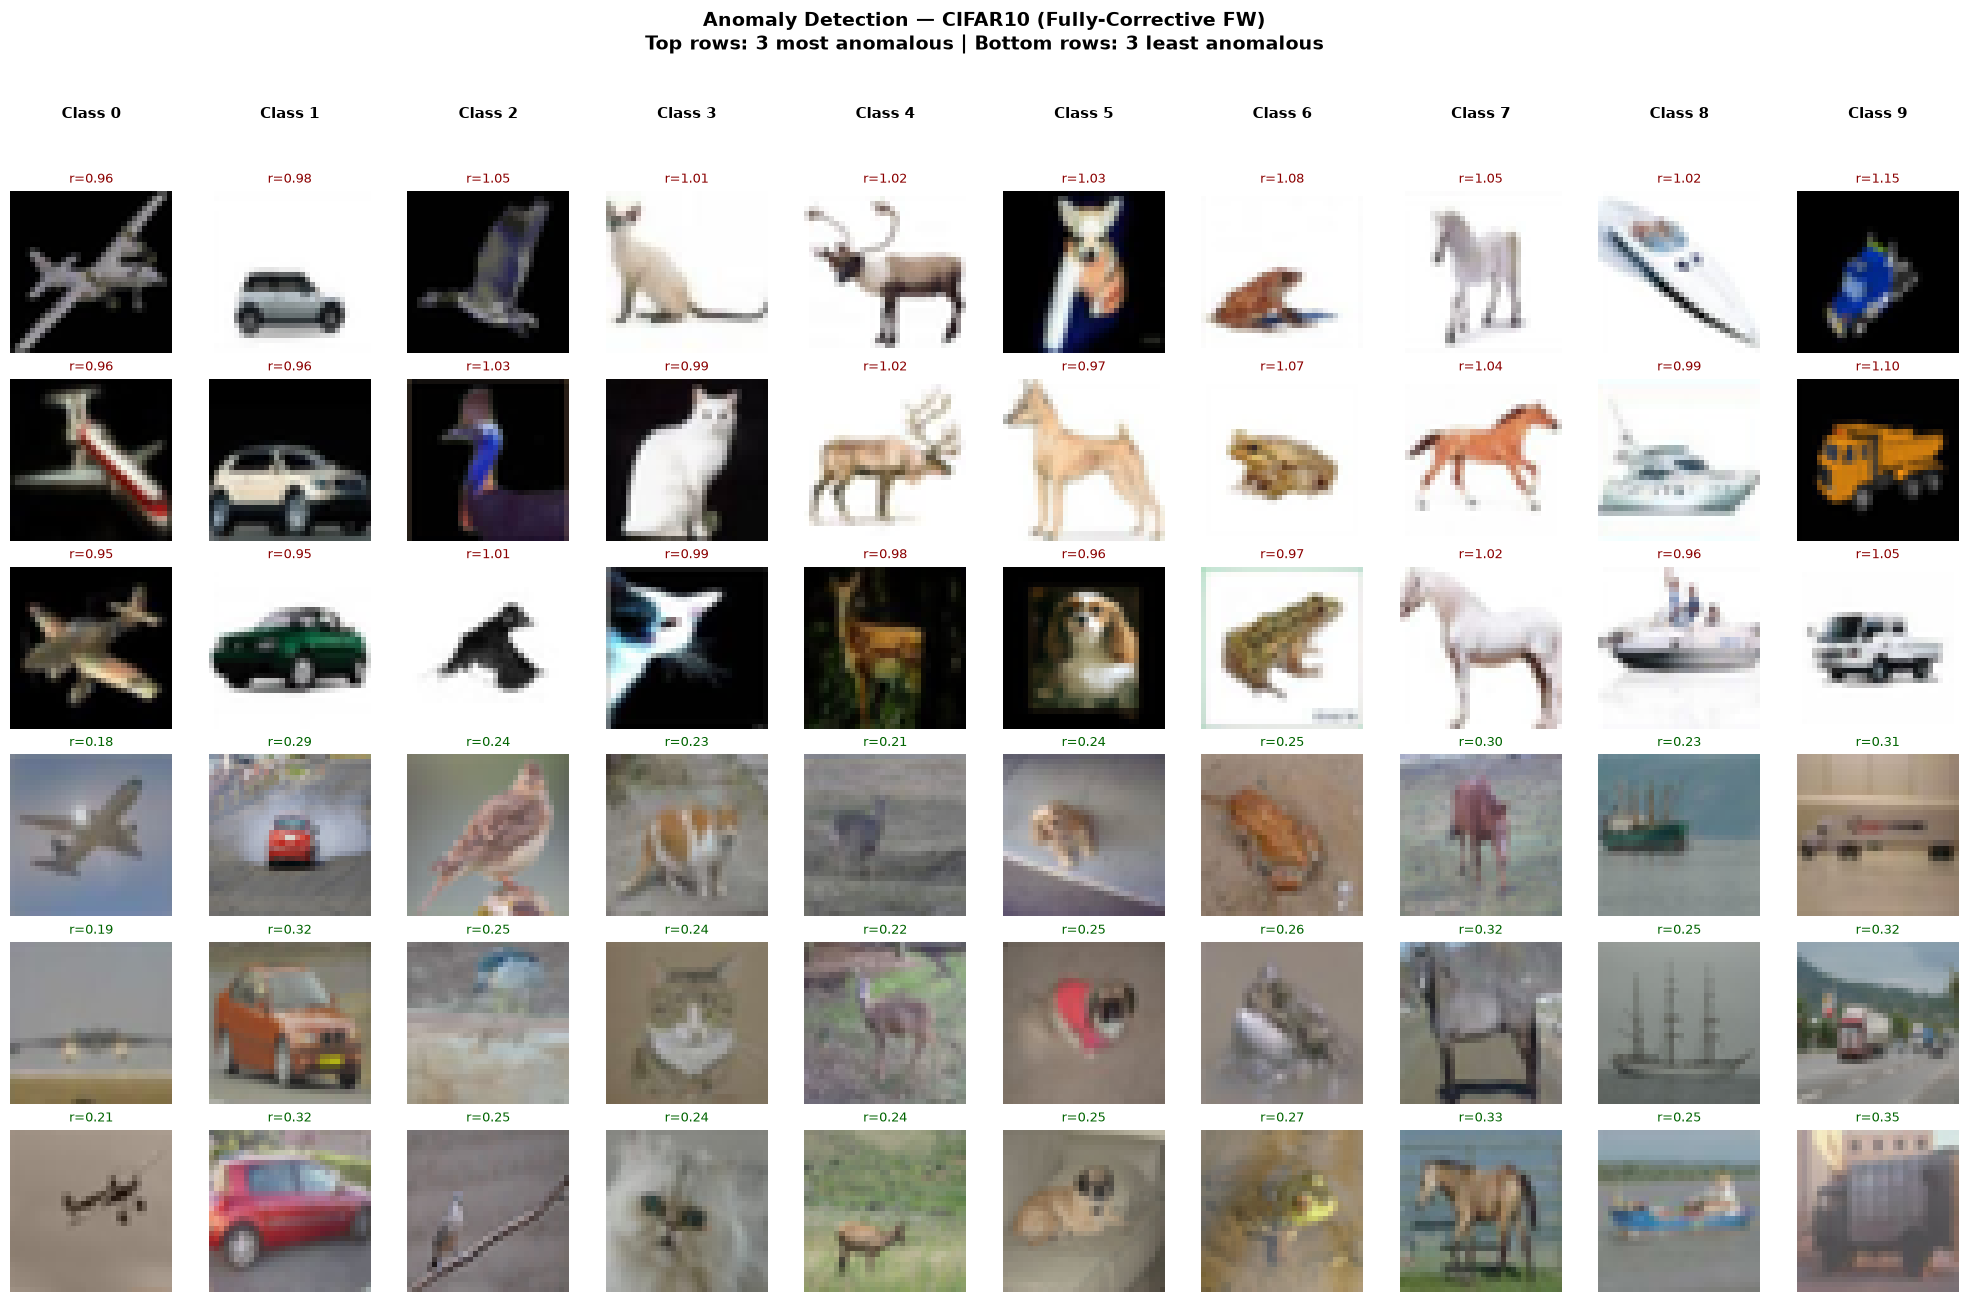

In [7]:
for ds_name in DATASETS:
    X_test = all_results[ds_name]["X_test"]
    y_test = all_results[ds_name]["y_test"]

    for solver_name, models in all_results[ds_name]["models"].items():
        print(f"\n{'=' * 80}\n  ANOMALY DETECTION -- {ds_name.upper()} | {solver_name}\n{'=' * 80}")
        distances, ratios = compute_anomaly_scores(models, X_test, y_test)
        outside = (ratios > 1.0).sum()
        print(f"Samples outside the MEB (ratio > 1): {outside} / {len(ratios)}")
        report_extreme_samples(models, X_test, y_test, ratios,
                                dataset_name=ds_name.upper(), solver_name=solver_name, k=3)
